# Reviewer Response Figures:


#### Setup

In [89]:
from pathlib import Path
import os
import notebook_setup
info = notebook_setup.setup()
# Environment & Imports Setup
import matplotlib as matplotlib
%matplotlib inline 

#code ocean step
use_code_ocean = False
if use_code_ocean:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import pandas as pd
import random
from datetime import datetime
from itertools import product

print(f"matplotlib {matplotlib.__version__} | Seaborn {sns.__version__}")
warnings.filterwarnings(action='ignore', category=FutureWarning)
pd.set_option('mode.use_inf_as_na', False) # pd.set_option('future.no_silent_downcasting', True)
np.random.seed(1) #set seed for reproducibility 
random.seed(1)
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
here = info["repo_root"]
print(f" Here: {here}")
_plot_posthoc_src = os.path.join(here, 'plot_posthoc_test', 'src')
if os.path.isdir(_plot_posthoc_src) and _plot_posthoc_src not in sys.path:
    sys.path.append(_plot_posthoc_src)
# Fix for seaborn 0.12.1 + pandas 2.0 compatibility
try:
    pd.get_option('mode.use_inf_as_null')
except (pd.errors.OptionError, KeyError):
    pd._config.config._global_config['mode']['use_inf_as_null'] = False
    pd._config.config._registered_options['mode.use_inf_as_null'] = pd._config.config.RegisteredOption(
        key='mode.use_inf_as_null',
        defval=False,
        doc="Deprecated",
        validator=lambda x: None,
        cb=None,
    )

#custom function import
import custom_module_imports as cmi 
from preprocess_data import hyper_param_dict, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import save_fig_in_main_fig_dir,  save_plot_record_as_csv_txt, make_folder, plot_heatmap_w_kwargs, annotate_csv
from ax_modifier_functions import add_spaces_linebreak_to_stage_ticks, set_ax_title_xlabel_ylabel, set_pointplot_edgecolor, set_labels, set_stage_xticks_2_layer
from sns_plotting_config import * #import dicts containing default plot params
from plot_posthoc_test.plot_stat_annotate import *
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
##Set/create save and load folder paths 
results_location = Path(here).parents[0] / "results"
data_location = Path(here).parents[0] / "data"
make_folder(results_location)
make_folder(data_location)
print(f"Saving results in {results_location}. Data location is {data_location}")
csv_folder_most_recent = results_location/ f"analysis_CSV_output/" #folders that analysis output goes to
make_folder(csv_folder_most_recent)

matplotlib 3.8.4 | Seaborn 0.12.1
Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
 Here: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results' already exists.
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data' already exists.
Saving results in c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results. Data location is c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output' already exists.


#### Autoencoder hidden layer/activation function comparison

In [90]:
# sweep_df_filename = r"_content_NN_param_sweep_02_Feb_2026_annotated_sweep_results_Early_IA_Error_v_Early_RS_Error_Early_RS_Error_WT VEH_Het VEH.parquet"
sweep_df_filename = r'_content_NN_param_sweep_14_Apr_2026_annotated_sweep_results_Early_IA_Error_v_Early_RS_Error_Early_RS_Error_WT VEH_Het VEH.parquet'
sweep_results_df = pd.read_parquet(data_location / Path(sweep_df_filename))

In [91]:
sweep_results_df

,train_db_index,train_loss,val_db_index,val_loss,activation,hidden_size,bootstrap_iter,ensemble,geno,comparison,run_end_time,n_frames_to_draw,n_epochs,n_bootstrap,val_fraction,BATCH_SIZE,axis
0,1.441236,0.066603,1.598966,0.073904,relu,2,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,14_Apr_2026,500,50,1000,0.3,500,0
1,1.034679,0.063746,1.159707,0.070184,relu,3,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,14_Apr_2026,500,50,1000,0.3,500,0
2,1.780185,0.056842,1.906653,0.063472,relu,4,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,14_Apr_2026,500,50,1000,0.3,500,0
3,1.189829,0.056659,1.412174,0.061815,relu,5,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,14_Apr_2026,500,50,1000,0.3,500,0
4,0.705007,0.067412,0.754669,0.073624,leaky_relu,2,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,14_Apr_2026,500,50,1000,0.3,500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,1.935702,0.041840,1.687725,0.036903,leaky_relu,5,999,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,14_Apr_2026,500,50,1000,0.3,500,0
23996,1.181920,0.060550,1.122181,0.054133,mish,2,999,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,14_Apr_2026,500,50,1000,0.3,500,0
23997,1.823348,0.054466,1.711034,0.047900,mish,3,999,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,14_Apr_2026,500,50,1000,0.3,500,0
23998,2.502630,0.047792,2.347222,0.043641,mish,4,999,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,14_Apr_2026,500,50,1000,0.3,500,0


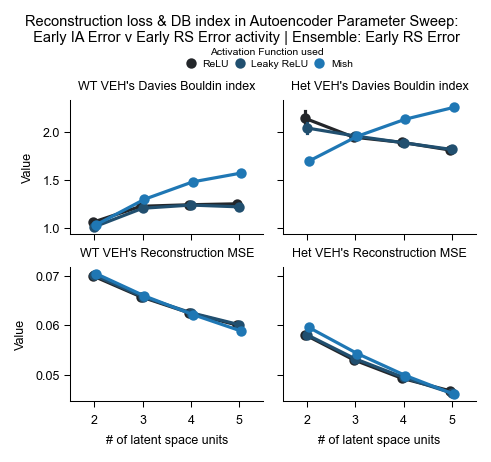

In [92]:
# Faceted pointplot: one panel per genotype
# set var names
comparison = sweep_results_df['comparison'].iloc[0]
ensemble = sweep_results_df['ensemble'].iloc[0]
# make plot
melt_sweep_df = sweep_results_df.melt(id_vars=['geno', 'activation', 'hidden_size'], 
                                        value_vars=['val_db_index', 'val_loss'], 
                                        var_name='metric', value_name='value')
melt_sweep_df['metric'] = melt_sweep_df['metric'].map({'val_db_index': 'Davies Bouldin index', 'val_loss': 'Reconstruction MSE'})
g = sns.FacetGrid(melt_sweep_df, col='geno',row = 'metric', height=1.5, aspect=1.1, sharey='row')
g.map_dataframe(sns.pointplot, x='hidden_size', y='value', hue='activation', dodge=True, errorbar='se')
g.set_titles("{col_name}'s {row_name}")
g.set_axis_labels("# of latent space units", "Value")
# Make room at top for suptitle AND legend
g.figure.subplots_adjust(top=0.8)
handles, labels = g.axes.flat[0].get_legend_handles_labels()
label_rename = {'relu': 'ReLU', 'leaky_relu': 'Leaky ReLU', 'mish': 'Mish'}
new_labels = [label_rename.get(label, label) for label in labels]
# Add legend at top center, between suptitle and plots
g.figure.legend(handles, new_labels, loc='upper center', bbox_to_anchor=(0.55, 0.93),ncol=len(new_labels),title="Activation Function used", frameon=False)
g.figure.suptitle(f"Reconstruction loss & DB index in Autoencoder Parameter Sweep:\n  {comparison.replace("_", " ")} activity | Ensemble: {ensemble.replace("_", " ")}",
                  y = 0.99, 
                  fontsize=7)
plt.savefig(f"sweep_results_{ensemble}.png", dpi=150, bbox_inches='tight')

In [93]:
# Quantify % decrease in reconstruction loss (val_loss) from ReLU to Mish
# Per (geno, hidden_size): mean val_loss for each activation, then compute % decrease
loss_by_act = (sweep_results_df
               .groupby(['geno', 'hidden_size', 'activation'])['val_loss']
               .mean()
               .unstack('activation'))
loss_by_act['pct_decrease_relu_to_mish'] = (
    (loss_by_act['relu'] - loss_by_act['mish']) / loss_by_act['relu'] * 100
)
print("Mean reconstruction loss (val_loss) by activation, with % decrease ReLU -> Mish:")
print(loss_by_act.round(5))

# Overall (pooled across geno and hidden_size)
overall_relu = sweep_results_df.loc[sweep_results_df['activation'] == 'relu', 'val_loss'].mean()
overall_mish = sweep_results_df.loc[sweep_results_df['activation'] == 'mish', 'val_loss'].mean()
overall_pct = (overall_relu - overall_mish) / overall_relu * 100
print(f"\nOverall mean val_loss  ReLU: {overall_relu:.5f} | Mish: {overall_mish:.5f}")
print(f"Overall % decrease in reconstruction loss (ReLU -> Mish): {overall_pct:.2f}%")


Mean reconstruction loss (val_loss) by activation, with % decrease ReLU -> Mish:
activation           leaky_relu     mish     relu  pct_decrease_relu_to_mish
geno    hidden_size                                                         
Het VEH 2               0.05810  0.05959  0.05808                   -2.59842
        3               0.05320  0.05430  0.05303                   -2.39416
        4               0.04943  0.04983  0.04927                   -1.12802
        5               0.04625  0.04604  0.04672                    1.46034
WT VEH  2               0.07023  0.07053  0.07011                   -0.60319
        3               0.06585  0.06601  0.06584                   -0.25147
        4               0.06260  0.06223  0.06257                    0.55016
        5               0.06016  0.05888  0.06008                    1.99167

Overall mean val_loss  ReLU: 0.05821 | Mish: 0.05843
Overall % decrease in reconstruction loss (ReLU -> Mish): -0.37%


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


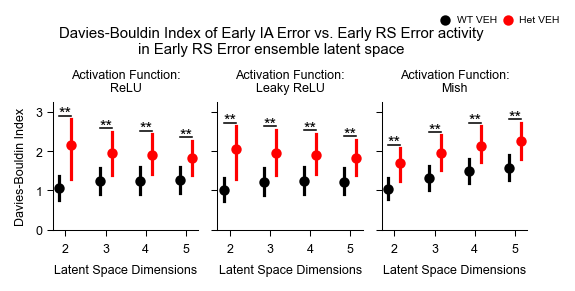

In [94]:
# FacetGrid: DB index by # latent units, faceted by activation function, dodged by genotype
geno_palette = {g: c for g, c in zip(geno_color_dict['hue_order'], geno_color_dict['palette'])}
db_df = sweep_results_df[sweep_results_df['geno'].isin(['WT VEH', 'Het VEH'])].copy()
db_df['geno'] = pd.Categorical(db_df['geno'], categories=['WT VEH', 'Het VEH'], ordered=True)
label_rename_act = {'relu': 'ReLU', 'leaky_relu': 'Leaky ReLU', 'mish': 'Mish'}
db_df['activation_label'] = db_df['activation'].map(label_rename_act)

## MAKE FIG
col_order = [label_rename_act[a] for a in ['relu', 'leaky_relu', 'mish']]
hue_order = ['WT VEH', 'Het VEH']
fig, axes = plt.subplots(1, len(col_order), figsize=(3.5, 1.75), layout='constrained',
                         sharey=True, sharex=True)
posthoc_df_list = []
for ax, act_label in zip(axes, col_order):
    subset = db_df[db_df['activation_label'] == act_label]
    plot_params = dict(data=subset, x='hidden_size', y='val_db_index', order = [2,3,4,5],
                   hue='geno', palette=geno_palette, hue_order=hue_order, linestyles='None',
                    dodge=0.3, errorbar=('pi', 75))
    sc = sns.pointplot( ax=ax,
                  **plot_params)
      ##annotate ax
    set_ax_title_xlabel_ylabel(ax, label_dict=dict(xlabel="Latent Space Dimensions",
                                                    title=f"Activation Function:\n{act_label}",
                                                    ylim = (0, 3.25),
                                                    ylabel="Davies-Bouldin Index" if ax == axes[0] else ""))
    ax.get_legend().remove()
    ## run post-hoc testing and annotate significant pairwise comparisons
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, sc, [('WT VEH', 'Het VEH')],
                                                            test_name = 'cohen_d',ax_var_is_hue = False,
                                                               detect_error_bar=True,plot_type= 'pointplot') # plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:])
    posthoc_df_list.append(posthoc_df)
    plot_sig_bars_w_comp_df_tight(ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:],tight_offset = 0.03,offset_constant=0.025)
    
  
## annotate ax 
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.8, 1.), ncol=2, frameon=False)
clean_comparison = comparison.replace('_', ' ').replace('v', 'vs.')
clean_ensemble = ensemble.replace('_', ' ')
fig.suptitle(f"Davies-Bouldin Index of {clean_comparison} activity\nin {clean_ensemble} ensemble latent space",)

save_fig_in_main_fig_dir(fig, fig_name="DB Index by Latent Size_Activation Function",
                         folder_key='r_1', filetypes_to_save=['png', 'svg'])

## Decoding # cells dropped:

#### create df with # of cells dropped by using union of activations for concat matrices

In [95]:
from helper_functions import get_trial_num_in_phase_by_dataset, get_ID_enriched_units_by_phase
from matrix_resample_utils import resample_into_class_matrix,  resample_combine_dict_of_activity_dfs,fast_pack_data_local 

In [96]:
#imported from autoencoder:
# ## helper functions imported from phase_enrich_timeseries_decode.py module
def get_dataset_names_in_geno(dataset_name_by_geno_day,
                              geno_day,
                              subject_name_col = 'subject_name'):
    datasets_in_geno = dataset_name_by_geno_day.loc[dataset_name_by_geno_day.geno_day == geno_day,subject_name_col].values[0] #get name of datasets in current geno_day setup
    return datasets_in_geno

 ## imported subfunc for cuDF speedup
def get_tseries_of_dataset(timeseries_df, 
                           dataset_name, 
                           subject_name_col = 'subject_name'):
    #get time-series that are occurign in phase of interest
    dataset_df_slice = timeseries_df.loc[timeseries_df[subject_name_col] == dataset_name]
    return dataset_df_slice

def get_tseries_in_phase(timeseries_df, phase_name):
    phase_dataset_df_slice = timeseries_df.loc[timeseries_df.task_phase_vec == phase_name]
    return phase_dataset_df_slice

def get_tseries_phase_enrich_cells(tseries_df, unit_ID_col, enrichment_ID_df, dataset_name, e_phase_name,subject_name_col = 'subject_name'):
    enrich_in_phase_unit_IDs = get_dataset_units_enrich_in_phase(enrichment_ID_df, unit_ID_col, dataset_name, e_phase_name, subject_name_col = subject_name_col) #get unit IDs that are enriched in phase of interest
    enrich_in_phase_dataset_df = tseries_df.loc[tseries_df[unit_ID_col].isin(enrich_in_phase_unit_IDs)]#get unit time-series only if they enriched in phase of interest
    return enrich_in_phase_dataset_df, enrich_in_phase_unit_IDs

def get_dataset_units_enrich_in_phase(enrich_unit_by_name_phase_df,
                                       unit_ID_col,
                                         dataset_name,
                                           stage_of_interest,
                                           subject_name_col = 'subject_name'):
    name_mask = enrich_unit_by_name_phase_df[subject_name_col] == dataset_name
    phase_mask = enrich_unit_by_name_phase_df.task_phase_vec == stage_of_interest
    enrich_in_phase_unit_IDs =enrich_unit_by_name_phase_df.loc[phase_mask&name_mask, unit_ID_col].values[0]
    return enrich_in_phase_unit_IDs

def horzcat_all_trials(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=False):
    if drop_pre_outcome:
        print("drop pre outcome called")
        tseries_cols = [col for col in tseries_cols if "-" not in col]
    grouped = {
        trial: group.set_index(unit_col_name)[tseries_cols]
        for trial, group in timeseries_df.groupby('trial_num', sort=False)
    }
    return pd.concat(grouped.values(), axis=1)

def horzcat_all_trials_original(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=False):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col] 
    trial_slice_storage = []
    for trial in timeseries_df.trial_num.unique():
        trial_slice = timeseries_df.loc[timeseries_df.trial_num == trial].set_index(unit_col_name)
        trial_slice_storage.append(trial_slice.loc[:,tseries_cols])
    return pd.concat(trial_slice_storage, axis=1)

def make_dataset_matrix_store_only(stage_names, 
                                   trial_tseries_df_norm,
                                   unit_ID_col,
                                   enrich_unit_ID_by_name_df,
                                    numeric_col,
                                    trial_list_by_dataset,
                                   dataset_name_by_geno_day,
                                   phase_enrichment_by_subj,
                                     subject_name_col = 'subject_name'):
    """TO- create a dict where key1 = stage the pseudopop is enriched in, key 2 = stage to look for activity of, and key 3- genotype of current datset"""
    ppop_data,stage_geno_tseries = dict(), dict()
    iter_ct = 0
    for e_phase in stage_names:
        ppop_data[e_phase],stage_geno_tseries[e_phase] = {},{}
        print("Get enrich in ",e_phase, "act. in ", stage_names)

        for act_phase in stage_names:
            datasets_w_phase_act = trial_list_by_dataset.loc[trial_list_by_dataset.task_phase_vec == act_phase][subject_name_col].unique()
            ppop_data[e_phase][act_phase],stage_geno_tseries[e_phase][act_phase]= {},{}

            for geno_day in dataset_name_by_geno_day.geno_day.unique():
                datasets_in_geno = get_dataset_names_in_geno(dataset_name_by_geno_day,geno_day, subject_name_col = subject_name_col)
                geno_dataset_w_act = [name for name in datasets_in_geno if name in datasets_w_phase_act]
                current_ppop_draw = dict()
                
                for dataset in geno_dataset_w_act:
                    iter_ct = iter_ct+1
                    #check if > 0 cells are enriched in stage
                    if phase_enrichment_by_subj.set_index(subject_name_col).loc[dataset, e_phase] > 0:
                        phase_dataset_df = get_tseries_in_phase(get_tseries_of_dataset(trial_tseries_df_norm,dataset, subject_name_col = subject_name_col), act_phase)
                        e_in_phase_data_df,e_in_stage_ID =get_tseries_phase_enrich_cells(phase_dataset_df, unit_ID_col,
                                                                                         enrich_unit_ID_by_name_df, dataset, e_phase, subject_name_col = subject_name_col)
                        current_ppop_draw[dataset] =  horzcat_all_trials_original(e_in_phase_data_df,numeric_col, unit_ID_col)
                ppop_data[e_phase][act_phase][geno_day] =current_ppop_draw
    return ppop_data

In [97]:
units = 'cells'
#declare loc/names of files to read
output_folder = os.getcwd() +"/output/"
use_new_dataset = True
use_dff = False
data_type = 'post_outcome_activity'
if use_new_dataset:
    #latest matlab run: 
    if use_dff:
        data_type = 'post_dff'
        new_trial_df_filename = data_location /  r"matlab_import_1000_shuff_minmax_normed_trial_tseries_26-Feb-2026\dff_matlab-made_trial_timeseries_normalized_2026-02-26 21.parquet"
    else:
        new_trial_df_filename = data_location /  r"matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet" # new matlab made 10k shuffle file     
    #if data is from new_dataset
    subject_col = 'subject_name'
    unit_ID_col = 'neuron_ID'
else: 
    new_trial_df_filename = f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
    #if data is from old dataset:
    subject_col = 'name'
    unit_ID_col = 'unique_ID'
# new_trial_df_filename = Path(r"python-made_trial_timeseries_raster_2025-12-21 12.parquet")

trial_df_filename = data_location /  new_trial_df_filename
print(f"loading_dataset {new_trial_df_filename} \n from {trial_df_filename}")
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
trial_tseries_df_norm.tail()


loading_dataset c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet 
 from c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet


,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,section,subject_name,session,raw_ID,day,...,pvalue_post_outcome_Late_RS,Run_end_time,num_shuffles,any_enrichment,enriched_in_phase,normalized,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial
116370,Late_RS,RS,Correct,38,9_3_HET_RS3-209,post_outcome,9_3_HET_RS3,RS3,209,3,...,0.4277,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.0150,True
116373,Late_RS,RS,Correct,38,9_3_HET_RS3-212,post_outcome,9_3_HET_RS3,RS3,212,3,...,0.4392,30-Jan-2026 17:20:28,10000,2.0,False,none,1.0,all_frames,0.0225,True
116374,Late_RS,RS,Correct,38,9_3_HET_RS3-213,post_outcome,9_3_HET_RS3,RS3,213,3,...,1.0000,30-Jan-2026 17:20:28,10000,0.0,False,none,1.0,all_frames,0.0000,False
116375,Late_RS,RS,Correct,38,9_3_HET_RS3-214,post_outcome,9_3_HET_RS3,RS3,214,3,...,0.0483,30-Jan-2026 17:20:28,10000,1.0,True,none,1.0,all_frames,0.1500,True
116376,Late_RS,RS,Correct,38,9_3_HET_RS3-215,post_outcome,9_3_HET_RS3,RS3,215,3,...,0.1055,30-Jan-2026 17:20:28,10000,0.0,False,none,0.8,all_frames,0.0000,False


In [98]:

#col names for analysis
stage_col = 'task_phase_vec'
stage_names = sorted(trial_tseries_df_norm[stage_col].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")


In [99]:

# Test
result_orig = horzcat_all_trials_original(trial_tseries_df_norm, numeric_col,unit_ID_col)
result_opt = horzcat_all_trials(trial_tseries_df_norm, numeric_col,unit_ID_col)

print("Identical:", result_orig.equals(result_opt))
print("Shape match:", result_orig.shape == result_opt.shape)
print("Columns match:", list(result_orig.columns) == list(result_opt.columns))
print("Index match:", list(result_orig.index) == list(result_opt.index))


Identical: True
Shape match: True
Columns match: True
Index match: True


In [100]:
## create class matrix storage as usual
trial_tseries_df_norm= trial_tseries_df_norm.assign(**{'any_enrichment':  trial_tseries_df_norm[stage_names].sum(axis = 1)})

## make accessory secondary dfs
trial_list_by_dataset = get_trial_num_in_phase_by_dataset( trial_tseries_df_norm, name_col = subject_col)
##important- threshold to take datasets with >1 trials per section ( to have enough space of neurons)
trial_list_by_dataset= trial_list_by_dataset[trial_list_by_dataset.count_of_trials >1]
enrich_unit_ID_by_name_df =get_ID_enriched_units_by_phase(trial_tseries_df_norm, ID_col= unit_ID_col, bool_col_tseries_enriched = 'enriched_in_phase', subj_name_col = subject_col )
dataset_name_by_geno_day = enrich_unit_ID_by_name_df.groupby('geno_day')[subject_col].unique().reset_index()


neuron_enrichment =  trial_tseries_df_norm.groupby([subject_col, 'geno_day', unit_ID_col])[stage_names].mean().reset_index()
phase_enrichment_by_subj = neuron_enrichment[list(stage_names) + [subject_col, 'geno_day']].groupby(by = [subject_col, 'geno_day']).sum().reset_index()


In [101]:
class_matrix_store  = make_dataset_matrix_store_only(stage_names, 
                                                     trial_tseries_df_norm,
                                                     unit_ID_col,
                                                     enrich_unit_ID_by_name_df,
                                                       numeric_col,
                                                         trial_list_by_dataset,
                                                         dataset_name_by_geno_day,
                                                         phase_enrichment_by_subj,
                                                         subject_name_col = subject_col )

Get enrich in  Early_IA_Correct act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_IA_Error act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_RS_Correct act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_RS_Error act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Late_IA act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Late_RS act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']


In [102]:
## set comparisons:|

phase_names = trial_tseries_df_norm.task_phase_vec.unique()
#determine comparisosn to be decoding on
class_comparisons = [
    [phase_names[0], phase_names[1]], #early IA corr vs. early IA err
    [phase_names[0], phase_names[3]],#- early IA corr vs. early RS corr
    [phase_names[1], phase_names[4]],#  - early IA err vs.l early RS err
    [phase_names[3], phase_names[4]],#- early RS corr vs. early RS err
    [phase_names[2], phase_names[5]],#- late IA vs. late RS
    [phase_names[0], phase_names[2]],#- early IA corr vs. late IA
    [phase_names[3], phase_names[5]],#- early RS corr vs. late RS
    [phase_names[2], phase_names[3]],#late IA vs early RS corr
                     ]

In [103]:
num_resample = 400
results = []
dropped_details = {}
    
for e_phase in stage_names:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
    for geno_day_curr in geno_order_w_WT_CLNZ: #set geno to use
                ensemble_resample_in_phase_dict = {}
                for class_name in stage_names:
                    class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, class_name, geno_day_curr)
                    ensemble_resample_in_phase_dict[class_name] = class_matrix
                
                #record dropped Ids 
                all_dropped_ids = set()

                for phase_count, phase_pair in enumerate(class_comparisons): #once genotype & enrichment filter, specified, compare phase detection
                    class_0,class_1 = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    ## make training set
                    class_mat_0 =ensemble_resample_in_phase_dict[class_0]
                    class_mat_1 =ensemble_resample_in_phase_dict[class_1]
                    concat_matrix,concat_labels =fast_pack_data_local(class_mat_0, class_mat_1,0,1)        #returns concat_matrix, and concat_labels
                    joined_ids = set(concat_matrix.index.values)  # Capture cell IDs BEFORE .T.values
                    concat_matrix = concat_matrix.T.values #.T.values of concat matrix is to reshape mat into what scikit wants from you

                    comp_info = {'comparison': "_v_".join(phase_pair),
                        'ensemble': e_phase,
                        'geno_day': geno_day_curr,
                        'class_0': class_0,
                        'class_1': class_1}
                    try:
                        # Get cell IDs before join
                        class_0_ids = set(class_mat_0.index)
                        class_1_ids = set(class_mat_1.index) 
                        
                        # Calculate dropped cells
                        unique_ids = class_0_ids | class_1_ids
                        dropped_from_class0 = class_0_ids - joined_ids
                        dropped_from_class1 = class_1_ids - joined_ids
                        all_dropped = (class_0_ids | class_1_ids) - joined_ids
                        all_dropped_ids.update(all_dropped)
                        
                        results.append({**comp_info, 
                            'n_class0': len(class_0_ids),
                            'n_class1': len(class_1_ids),
                            'n_after_join': len(joined_ids),
                            'n_dropped_from_class0': len(dropped_from_class0),
                            'n_dropped_from_class1': len(dropped_from_class1),
                            'n_total_dropped': len(all_dropped),
                            'n_total_unique_ids': len(unique_ids),
                            'dropped_ids': all_dropped,
                            'class_0_ids': class_0_ids,
                            'class_1_ids': class_1_ids,
                            'joined_ids': joined_ids
                            })
                        
                    except KeyError as e:
                        # Handle missing data for this combination
                        results.append({**comp_info,
                             'n_class0': 0, 
                             'n_class1': 0, 
                             'n_after_join': 0,
                             'n_dropped_from_class0': 0,
                               'n_dropped_from_class1': 0,
                            'n_total_dropped': 0, 
                            'dropped_ids': set(),
                            'error': str(e)})
                            ## save # ids in class_mat 0 vs class_mat_1

drop_cells = pd.DataFrame(results)
drop_cells['prop_dropped_ids'] = drop_cells['n_total_dropped'] / drop_cells['n_total_unique_ids']
drop_cells                   

,comparison,ensemble,geno_day,class_0,class_1,n_class0,n_class1,n_after_join,n_dropped_from_class0,n_dropped_from_class1,n_total_dropped,n_total_unique_ids,dropped_ids,class_0_ids,class_1_ids,joined_ids,prop_dropped_ids
0,Early_IA_Correct_v_Early_IA_Error,Early_IA_Correct,WT VEH,Early_IA_Correct,Early_IA_Error,109,51,51,58,0,58,109,"{13_6_WT_RS1-112, 13_6_WT_RS1-78, 7_4_WT_RS1-6...","{13_6_WT_RS1-112, 13_6_WT_RS1-78, 5_3_WT_RS1-8...","{13_4_WT_RS1-2, 5_3_WT_RS1-82, 13_4_WT_RS1-76,...","{13_4_WT_RS1-2, 5_3_WT_RS1-82, 13_4_WT_RS1-76,...",0.532110
1,Early_IA_Correct_v_Early_RS_Correct,Early_IA_Correct,WT VEH,Early_IA_Correct,Early_RS_Correct,109,109,109,0,0,0,109,{},"{13_6_WT_RS1-112, 13_6_WT_RS1-78, 5_3_WT_RS1-8...","{13_6_WT_RS1-112, 13_6_WT_RS1-78, 5_3_WT_RS1-8...","{13_6_WT_RS1-112, 13_6_WT_RS1-78, 5_3_WT_RS1-8...",0.000000
2,Early_IA_Error_v_Early_RS_Error,Early_IA_Correct,WT VEH,Early_IA_Error,Early_RS_Error,51,77,35,16,42,58,93,"{13_6_WT_RS1-112, 13_6_WT_RS1-78, 7_4_WT_RS1-6...","{13_4_WT_RS1-2, 5_3_WT_RS1-82, 13_4_WT_RS1-76,...","{13_6_WT_RS1-112, 13_6_WT_RS1-78, 5_3_WT_RS1-8...","{5_3_WT_RS1-82, 6_2_WT_RS1-55, 7_5_WT_RS1-140,...",0.623656
3,Early_RS_Correct_v_Early_RS_Error,Early_IA_Correct,WT VEH,Early_RS_Correct,Early_RS_Error,109,77,77,32,0,32,109,"{13_4_WT_RS1-2, 14_2_WT_RS1-107, 14_2_WT_RS1-1...","{13_6_WT_RS1-112, 13_6_WT_RS1-78, 5_3_WT_RS1-8...","{13_6_WT_RS1-112, 13_6_WT_RS1-78, 5_3_WT_RS1-8...","{13_6_WT_RS1-112, 13_6_WT_RS1-78, 5_3_WT_RS1-8...",0.293578
4,Late_IA_v_Late_RS,Early_IA_Correct,WT VEH,Late_IA,Late_RS,109,109,109,0,0,0,109,{},"{13_6_WT_RS1-112, 13_6_WT_RS1-78, 5_3_WT_RS1-8...","{13_6_WT_RS1-112, 13_6_WT_RS1-78, 5_3_WT_RS1-8...","{13_6_WT_RS1-112, 13_6_WT_RS1-78, 5_3_WT_RS1-8...",0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,Early_RS_Correct_v_Early_RS_Error,Late_RS,Het postCLNZ,Early_RS_Correct,Early_RS_Error,42,35,35,7,0,7,42,"{13_5_HET_RS3-109, 13_5_HET_RS3-91, 13_5_HET_R...","{10_3_HET_RS3-20, 13_8_HET_RS3-69, 10_3_HET_RS...","{10_3_HET_RS3-20, 13_8_HET_RS3-69, 10_3_HET_RS...","{10_3_HET_RS3-20, 13_8_HET_RS3-69, 10_3_HET_RS...",0.166667
236,Late_IA_v_Late_RS,Late_RS,Het postCLNZ,Late_IA,Late_RS,42,42,42,0,0,0,42,{},"{10_3_HET_RS3-20, 13_8_HET_RS3-69, 10_3_HET_RS...","{10_3_HET_RS3-20, 13_8_HET_RS3-69, 10_3_HET_RS...","{10_3_HET_RS3-20, 13_8_HET_RS3-69, 10_3_HET_RS...",0.000000
237,Early_IA_Correct_v_Late_IA,Late_RS,Het postCLNZ,Early_IA_Correct,Late_IA,42,42,42,0,0,0,42,{},"{10_3_HET_RS3-20, 13_8_HET_RS3-69, 10_3_HET_RS...","{10_3_HET_RS3-20, 13_8_HET_RS3-69, 10_3_HET_RS...","{10_3_HET_RS3-20, 13_8_HET_RS3-69, 10_3_HET_RS...",0.000000
238,Early_RS_Correct_v_Late_RS,Late_RS,Het postCLNZ,Early_RS_Correct,Late_RS,42,42,42,0,0,0,42,{},"{10_3_HET_RS3-20, 13_8_HET_RS3-69, 10_3_HET_RS...","{10_3_HET_RS3-20, 13_8_HET_RS3-69, 10_3_HET_RS...","{10_3_HET_RS3-20, 13_8_HET_RS3-69, 10_3_HET_RS...",0.000000


8 comparisons


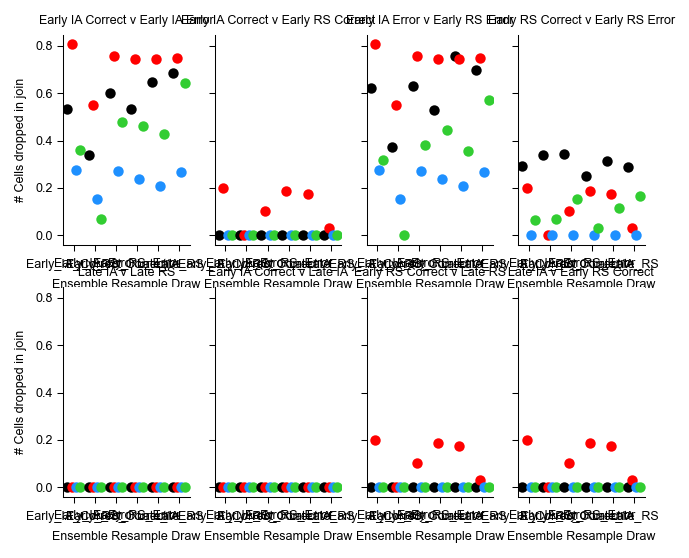

In [104]:
#    concat_matrix = class_0_mat.join(class_1_mat, how = 'inner', lsuffix = '_c0', rsuffix = '_c1') #use inner to avoid having missing cells in a condition if dataset missing that phase's trials
n_comparisons = drop_cells['comparison'].nunique()
print(f"{n_comparisons} comparisons")
fig,axes = plt.subplots(2, n_comparisons//2, figsize=(5,4), sharey= True)

##facet by comparison:
for comp_count, comparison in enumerate(drop_cells['comparison'].unique()):
    comp_df = drop_cells[drop_cells['comparison']== comparison]
    ax = axes.flat[comp_count]
    sns.stripplot(data =comp_df, ax = ax, x = 'ensemble', y = 'prop_dropped_ids', dodge = 0.4, **geno_color_dict_no_errorbar)
    set_labels(ax, label_dict = {'xlabel': "Ensemble Resample Draw", 'ylabel': "# Cells dropped in join", 'title': comparison.replace("_", " ")})    
    ax.get_legend().remove()

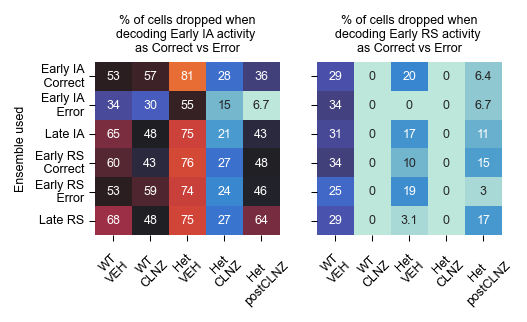

In [105]:
from ax_modifier_functions import add_xtick_color_boxes

## NEW- focus on comparisons important to main decoding results (early IA corr vs early IA err, and early RS corr vs. early RS err)
major_comparisons = ['Early_IA_Correct_v_Early_IA_Error', 'Early_RS_Correct_v_Early_RS_Error']
verbose_decoded_pairs = ['Early IA activity \nas Correct vs Error', 'Early RS activity \nas Correct vs Error']
fig,axes = plt.subplots(1, len(major_comparisons), figsize=(3.5,1.5))
##facet by comparison:
for comp_count, comparison in enumerate(major_comparisons):
    comp_df = drop_cells[drop_cells['comparison']== comparison]
    ax = axes.flat[comp_count]
    table_df = comp_df.pivot(index='ensemble', columns='geno_day', values='prop_dropped_ids')*100
    plot_df = table_df.loc[stage_chrono_order,geno_order_w_WT_CLNZ]
    sns.heatmap(data = plot_df, center = 50, cbar = False, annot=True, ax=ax)
    ## set labels
    ax.set_yticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_yticklabels()), rotation=0)
    if comp_count > 0:
        ax.set_yticklabels([])
        #remove ytickmarks too
        ax.spines['left'].set_visible(False)
    ax.set_xticklabels([label.get_text().replace(" ", "\n") for label in ax.get_xticklabels()], rotation=45)
    set_labels(ax, label_dict = {'xlabel': None, 'ylabel': {True:  "Ensemble used", False: ""}[comp_count ==0],
                                  'title': f"% of cells dropped when\ndecoding {verbose_decoded_pairs[comp_count]}"})


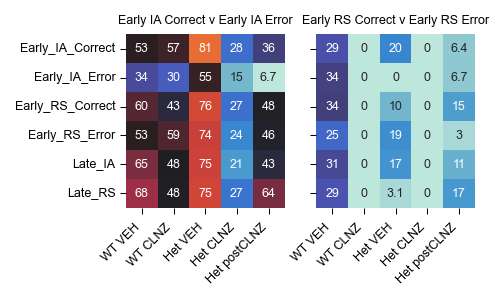

In [106]:
## NEW- focus on comparisons important to main decoding results (early IA corr vs early IA err, and early RS corr vs. early RS err)
secondary_comparisons = ['Early_IA_Correct_v_Early_IA_Error', 'Early_RS_Correct_v_Early_RS_Error']
fig,axes = plt.subplots(1, len(secondary_comparisons), figsize=(3,1.5), sharey= True,sharex= True)
##facet by comparison:
for comp_count, comparison in enumerate(secondary_comparisons):
    comp_df = drop_cells[drop_cells['comparison']== comparison]
    ax = axes.flat[comp_count]
    table_df = comp_df.pivot(index='ensemble', columns='geno_day', values='prop_dropped_ids')*100
    sns.heatmap(data = table_df.loc[stage_names,geno_order_w_WT_CLNZ], 
                cbar = False, center = 50, annot=True, ax=ax)
    ## set labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ylabel = {True:  "Ensemble Resample Draw", False: ""}
    set_labels(ax, label_dict = {'xlabel': None, 'ylabel': ylabel[False], 'title': comparison.replace("_", " ")})

In [107]:
class_mat_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 10_3_HET_RS3-13 to 9_3_HET_RS3-214
Columns: 400 entries, 0 to 399
dtypes: float64(400)
memory usage: 132.6+ KB


In [108]:
class_mat_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 10_3_HET_RS3-13 to 9_3_HET_RS3-214
Columns: 400 entries, 0 to 399
dtypes: float64(400)
memory usage: 132.6+ KB


<Axes: >

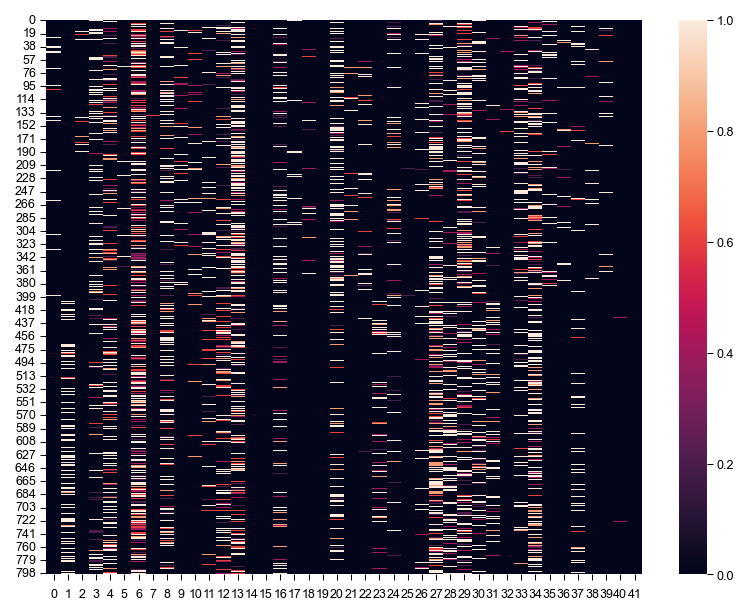

In [109]:
sns.heatmap(concat_matrix)

## Compare DFF vs Spikes ensemble values

#### import dff & spike datasets

In [110]:
#set what dataset to use, therefore waht col names are improtant 
use_new_dataset = True
if use_new_dataset:
    #if data is from new_dataset
    subject_col = 'subject_name'
    unit_ID_col = 'neuron_ID'
else:   
    #if data is from old dataset:
    subject_col = 'name'
    unit_ID_col = 'unique_ID'
stage_col = 'task_phase_vec'


In [111]:
#load spike data:


trial_df_filename = data_location /  r"matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet"
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
#once loaded, derive info from metadata
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
# get trial summary info
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = unit_ID_col, subj_name_col = 'subject_name')#.rename({unit_ID_col: "unique_ID"},axis = 1) # get subj level dfs
n_total_units = trial_tseries_df_norm.groupby(by = 'geno_day')[unit_ID_col].nunique()

#get processed dataset 
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], [subject_col, unit_ID_col,'geno_day', stage_col], numeric_col)
print(n_total_units)

geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: neuron_ID, dtype: int64


In [112]:
enriched_spikes = unit_mean_tseries.groupby(by = ['subject_name', unit_ID_col, 'geno_day'])[stage_names].first()
enriched_spikes

Early_IA_Correct  Early_IA_Error  \
subject_name neuron_ID        geno_day                                         
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH                      0             1.0   
             10_3_HET_RS1-10  Het VEH                      0             1.0   
             10_3_HET_RS1-101 Het VEH                      0             0.0   
             10_3_HET_RS1-104 Het VEH                      0             0.0   
             10_3_HET_RS1-107 Het VEH                      0             0.0   
...                                                      ...             ...   
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-96   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-97   Het postCLNZ                 0             1.0   
             9_3_HET_RS3-98   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-99   Het postCLNZ                 0             0.0   

                                            Early_RS_Correct  Early_RS_Error  \
subject_name neuron_ID        geno_day                                         
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH                      0               0   
             10_3_HET_RS1-10  Het VEH                      0               0   
             10_3_HET_RS1-101 Het VEH                      0               0   
             10_3_HET_RS1-104 Het VEH                      0               1   
             10_3_HET_RS1-107 Het VEH                      0               0   
...                                                      ...             ...   
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ                 0               0   
             9_3_HET_RS3-96   Het postCLNZ                 0               0   
             9_3_HET_RS3-97   Het postCLNZ                 0               0   
             9_3_HET_RS3-98   Het postCLNZ                 0               0   
             9_3_HET_RS3-99   Het postCLNZ                 0               0   

                                            Late_IA  Late_RS  
subject_name neuron_ID        geno_day                        
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH             0        0  
             10_3_HET_RS1-10  Het VEH             0        0  
             10_3_HET_RS1-101 Het VEH             0        0  
             10_3_HET_RS1-104 Het VEH             1        0  
             10_3_HET_RS1-107 Het VEH             0        0  
...                                             ...      ...  
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ        0        0  
             9_3_HET_RS3-96   Het postCLNZ        0        0  
             9_3_HET_RS3-97   Het postCLNZ        0        0  
             9_3_HET_RS3-98   Het postCLNZ        0        0  
             9_3_HET_RS3-99   Het postCLNZ        0        0  

[4776 rows x 6 columns]

In [113]:
# load DFF data
dff_file = data_location / Path(r"matlab_import_1000_shuff_minmax_normed_trial_tseries_26-Feb-2026\dff_matlab-made_trial_timeseries_normalized_2026-02-26 21.parquet")
trial_tseries_df_norm_dff = pd.read_parquet(dff_file)
n_total_units_dff = trial_tseries_df_norm_dff.groupby(by = 'geno_day')[unit_ID_col].nunique()
#make dff mean timeseries
unit_mean_tseries_dff =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm_dff,['trial_num'], [subject_col, unit_ID_col,'geno_day', stage_col], numeric_col)

print(n_total_units_dff)


geno_day
Het CLNZ        1094
Het VEH         1094
Het postCLNZ    1177
WT CLNZ         1246
WT VEH          1350
Name: neuron_ID, dtype: int64


In [114]:
enriched_dff = unit_mean_tseries_dff.groupby(by = ['subject_name', unit_ID_col, 'geno_day'])[stage_names].first()
enriched_dff

Early_IA_Correct  Early_IA_Error  \
subject_name neuron_ID        geno_day                                         
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH                      0             1.0   
             10_3_HET_RS1-10  Het VEH                      0             1.0   
             10_3_HET_RS1-100 Het VEH                      0             0.0   
             10_3_HET_RS1-101 Het VEH                      0             0.0   
             10_3_HET_RS1-102 Het VEH                      0             0.0   
...                                                      ...             ...   
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-96   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-97   Het postCLNZ                 0             1.0   
             9_3_HET_RS3-98   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-99   Het postCLNZ                 0             0.0   

                                            Early_RS_Correct  Early_RS_Error  \
subject_name neuron_ID        geno_day                                         
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH                      0               0   
             10_3_HET_RS1-10  Het VEH                      0               1   
             10_3_HET_RS1-100 Het VEH                      0               0   
             10_3_HET_RS1-101 Het VEH                      0               0   
             10_3_HET_RS1-102 Het VEH                      0               0   
...                                                      ...             ...   
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ                 0               0   
             9_3_HET_RS3-96   Het postCLNZ                 0               0   
             9_3_HET_RS3-97   Het postCLNZ                 0               0   
             9_3_HET_RS3-98   Het postCLNZ                 0               0   
             9_3_HET_RS3-99   Het postCLNZ                 0               0   

                                            Late_IA  Late_RS  
subject_name neuron_ID        geno_day                        
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH             0        0  
             10_3_HET_RS1-10  Het VEH             0        0  
             10_3_HET_RS1-100 Het VEH             0        0  
             10_3_HET_RS1-101 Het VEH             0        0  
             10_3_HET_RS1-102 Het VEH             0        0  
...                                             ...      ...  
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ        0        0  
             9_3_HET_RS3-96   Het postCLNZ        0        0  
             9_3_HET_RS3-97   Het postCLNZ        0        0  
             9_3_HET_RS3-98   Het postCLNZ        0        0  
             9_3_HET_RS3-99   Het postCLNZ        0        0  

[5961 rows x 6 columns]

#### Reviewer figure: Heatmap of dff

In [115]:
##Define functions to use for activity matrix creation
def get_df_unit_mean_activity_matrix(unit_mean_tseries, 
                                     stage_names,
                                     numeric_col, 
                                     subj_name_col:str = 'subject_name', 
                                     ignore_pre:bool = True):
    all_geno_matrix,  all_geno_IDs= get_unit_mean_phase_activity_matrix( unit_mean_tseries, 
                                                                        use_enrich_unit_only=  False,
                                                                          stage_names =  stage_names,
                                                                          numeric_col =  numeric_col,
                                                                           subj_name_col = subj_name_col,
                                                                            unit_ID_col = unit_ID_col,
                                                                             ignore_pre= ignore_pre)
    mean_AV_matrix = pd.DataFrame(data =np.nanmean(all_geno_matrix, axis = 1), columns = stage_names, index = all_geno_IDs).merge(
        unit_mean_tseries.groupby(unit_ID_col)['geno_day'].first().to_frame(),left_index = True, right_index = True)
    if np.nanmean(mean_AV_matrix.loc[:, stage_names].sum(axis = 1) == 0)>0:
        mean_AV_matrix = mean_AV_matrix.loc[(mean_AV_matrix.loc[:, stage_names].sum(axis = 1) > 0),:]
    return mean_AV_matrix

## preprocessing and normalization steps
def get_unit_mean_phase_activity_matrix(unit_mean_tseries, 
                                        use_enrich_unit_only,
                                          stage_names,
                                            numeric_col,
                                            subj_name_col = 'subject_name',
                                             unit_ID_col = 'neuron_ID',
                                              ignore_pre:bool= True, ):
    '''#TO- create matrix that's = concatenated vectors of all neuron mean activationni phase (output matrix = # units x # phases)    OUTPUT- '''
    matrix_IDs, stack_matrix,nan_df_list = dict(), dict(),[]
    skip_rec = dict()
    ## if going to skip pre-outcome period, change what counts as numeric col
    if ignore_pre:
        numeric_col = [col for col in numeric_col if '-' not in col]
    for dataset in unit_mean_tseries[subj_name_col].unique():
        matrix_list = []
        dataset_df = unit_mean_tseries.loc[ (unit_mean_tseries[subj_name_col] == dataset),:]
        if len(dataset_df.task_phase_vec.unique()) < len(stage_names):#check that dataset has ALL 6 phases, if not, skip
            skip_rec[dataset] = len(dataset_df.task_phase_vec.unique())
            # continue
        for stage in stage_names:
            phase_mask = (dataset_df.task_phase_vec == stage)
            matrix = dataset_df.loc[phase_mask, numeric_col].values #get phase entries, producing (dataset_neuron) x (time_bin matrix)
            #check if phase is present, if matrix extracted w phase trials is empty, assume mous elacks it
            if matrix.shape[0] == 0:
                matrix = np.tile(np.nan, (len(dataset_df[unit_ID_col].unique()), len(numeric_col)))
            if np.sum(np.isnan(matrix))>0:
                nan_df_list.append( dataset_df.loc[phase_mask, numeric_col])
            matrix_list.append(matrix)
        stack_matrix[dataset] = np.dstack(matrix_list)
        matrix_IDs[dataset] = dataset_df.loc[phase_mask, unit_ID_col].values
    all_geno_matrix = np.concatenate([val for val in stack_matrix.values()], axis = 0)
    all_geno_IDs =  np.concatenate([val for val in matrix_IDs .values()], axis = 0)
    return all_geno_matrix, all_geno_IDs

## extract tseries of interest to create AV matrix
ID_col_to_drop = 'cell' 
AV_matrix = get_df_unit_mean_activity_matrix(unit_mean_tseries_dff, stage_names, numeric_col,subj_name_col = 'subject_name', ignore_pre =True) # other way will not work: # AV_matrix =  get_df_unit_mean_activity_matrix(trial_tseries_df, stage_names, numeric_col)
AV_matrix['max_phase'] =AV_matrix[stage_names].idxmax(axis = 'columns')
max_95th_quantile = round(AV_matrix[stage_names].quantile(q = 0.95).max(),2)
min_5th_quantile = round(AV_matrix[stage_names].quantile(q = 0.05).min(),2)
print(f"5th percentile mean activation: {min_5th_quantile}, 95th percentile: {max_95th_quantile}")
WT_mask = AV_matrix.geno_day == "WT VEH"
AV_matrix['max_phase_val'] =AV_matrix.apply(lambda x: x[x.max_phase], axis = 1)
AV_matrix['max_phase'] =AV_matrix['max_phase'].apply(lambda x: stage_chrono_order.index(x))

no_Early_IA_Error = AV_matrix.Early_IA_Error.isna()
has_Early_IA_Error = ~no_Early_IA_Error
AV_matrix.tail()

5th percentile mean activation: -0.44, 95th percentile: 1.77


C:\Users\13car\AppData\Local\Temp\ipykernel_42380\819604394.py:14: RuntimeWarning: Mean of empty slice
  mean_AV_matrix = pd.DataFrame(data =np.nanmean(all_geno_matrix, axis = 1), columns = stage_names, index = all_geno_IDs).merge(


,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,geno_day,max_phase,max_phase_val
9_3_HET_RS3-95,-0.333195,0.087563,-0.146866,-0.292228,0.049979,0.127020,Het postCLNZ,5,0.127020
9_3_HET_RS3-96,-0.272123,0.898245,0.664034,-0.285116,-0.272407,-0.231106,Het postCLNZ,1,0.898245
9_3_HET_RS3-97,0.413765,3.780134,-0.268930,0.037388,-0.067772,0.014236,Het postCLNZ,1,3.780134
9_3_HET_RS3-98,-0.143967,-0.113177,-0.181281,-0.214394,-0.199272,-0.196949,Het postCLNZ,1,-0.113177
9_3_HET_RS3-99,-0.276386,-0.363606,-0.264345,0.040973,0.009452,-0.179825,Het postCLNZ,4,0.040973


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


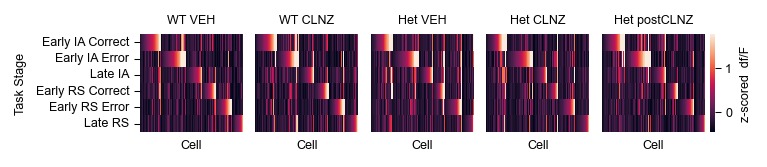

In [116]:
#plot unit heatmap for ALL GENOS
fig_mean_activity, axes = plt.subplots(1,5,figsize = (5,1), layout = 'constrained')
activity_type =  f"z-scored "
heatmap_clabel = activity_type

for count, geno in enumerate(geno_order_w_WT_CLNZ):
    plot_mask = (AV_matrix.geno_day == geno) & has_Early_IA_Error
    plot_data = AV_matrix.sort_values(by = ['max_phase','max_phase_val'],ascending = True).loc[plot_mask, stage_chrono_order].T
    plot_heatmap_w_kwargs(data =plot_data.rename(index = {p:p.replace('_', ' ') for p in plot_data.index}), ax =axes.flat[count],
                          kwarg_dict = {
                              'vmin': min_5th_quantile, 'vmax':max_95th_quantile, 'cbar_kws': {'label': f"{heatmap_clabel} df/F"},
                              'cbar': {True: True, False: False}[count == len(geno_order_w_WT_CLNZ)-1], 'yticklabels': True, 'xticklabels':False},
                          label_dict = {'xlabel': f"Cell", 'ylabel': {False:"Task Stage", True: None}[count > 0], 'title': geno})#plot heatmap
    axes.flat[count].set_yticks({True:[], False: axes.flat[count].get_yticks()}[count > 0])
#save figs
fig_prefix = "supp_" #for sorting in folder
fig_name = 'one_row_cell stage-activity sorted heatmap'
fig_mean_activity.get_axes()
save_fig_in_main_fig_dir(fig_mean_activity, fig_name= fig_name, folder_key='r_1', filetypes_to_save = ['png', 'svg'])

#### Reviewer figure- compute ensemble size/distribution

In [117]:
#calculate distribution of enrichment in dff data
unique_ID_enrichment_dff = unit_mean_tseries_dff.groupby(by = ['geno_day', unit_ID_col])[stage_names].first()
# bin_ends = get_numeric_col_bin_end_float(numeric_col)
geno_mean_enrich_dff = unique_ID_enrichment_dff.groupby('geno_day').agg({ **{p: 'mean' for p in stage_names}}).reset_index().melt(id_vars = 'geno_day', var_name = 'phase', value_name = 'prop_enriched')
prop_of_cells_enrich_n_stages_dff = unique_ID_enrichment_dff.sum(axis=1).rename('num_enrich').groupby('geno_day').value_counts(normalize=True).rename('prop_enrich').reset_index()
prop_of_cells_enrich_n_stages_dff.head()

,geno_day,num_enrich,prop_enrich
0,Het CLNZ,0.0,0.690128
1,Het CLNZ,1.0,0.192870
2,Het CLNZ,2.0,0.065814
3,Het CLNZ,3.0,0.035649
4,Het CLNZ,4.0,0.011883


In [118]:
geno_mean_enrich_dff.head()

,geno_day,phase,prop_enriched
0,Het CLNZ,Early_IA_Correct,0.118830
1,Het VEH,Early_IA_Correct,0.164534
2,Het postCLNZ,Early_IA_Correct,0.139337
3,WT CLNZ,Early_IA_Correct,0.117978
4,WT VEH,Early_IA_Correct,0.112593


In [119]:
import helper_functions
print(dir(helper_functions))

['DEFAULT_DATE_FORMAT', 'Path', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'add_bin_end_col', 'add_dict_field_to_dicts', 'add_spaces_linebreak_to_stage_ticks', 'add_unique_ID_col_to_trial_series_df', 'annotate_csv', 'axmod', 'bin_post_outcome', 'cdist', 'check_if_row_has_nan', 'datetime', 'dfanno', 'drop_partial_bin', 'fig_nums', 'fig_save_dir', 'find_n_bins_pre_post_get_new_bin_mapper', 'flatten_2_row_mosaic', 'full_annotate_2_phase_table', 'get_ID_enriched_units_by_phase', 'get_PCA_obj_and_transform_matrix', 'get_PCA_scatter_kwarg_dict', 'get_ax_linedata_and_y_offset', 'get_best_fit_line', 'get_bin_end_str', 'get_bool_category_vecs', 'get_class_AVs', 'get_col_w_str', 'get_correct_error_str_list', 'get_cosine_sim', 'get_cosine_sim_of_class_AVs', 'get_datetag', 'get_df_unit_mean_activity_matrix', 'get_early_rule_str_list', 'get_frame_cols', 'get_frame_nonframe_cols_of_tseries', 'get_geno_comparisons_stratefied_by_phase', 'g

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


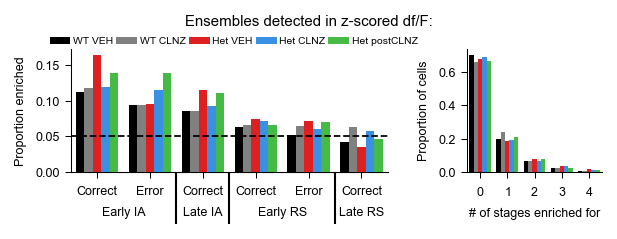

In [120]:
fig, axes = plt.subplots(1,2, figsize = (4,1.25), layout = 'constrained', width_ratios = [0.7, 0.3], gridspec_kw = dict(wspace = 0.1))


ax_prop_enrich = axes[0]
g = sns.barplot(ax =ax_prop_enrich, data =geno_mean_enrich_dff, x = 'phase', y = r'prop_enriched',order = phase_list_IA_RS_chrono, **geno_color_dict_w_WT_CLNZ)
ax_prop_enrich.axhline(y = 0.05, color = 'black', linestyle = '--')
sec, sec2, is_dict = set_stage_xticks_2_layer(ax_prop_enrich, phase_list_IA_RS_chrono) ## given ordering of xposition, get the list of what ticks are belonging to what task stage
set_ax_title_xlabel_ylabel(ax_prop_enrich, {'title': None,'ylim': [0, None], 'legend_false':True, 'ylabel':  f"Proportion enriched", 'xlabel': None})#f"Task Stage"}) #f' Prop. of cells active > shuffle 95%ile'

##plot the distribution of values
ax_barplot = axes[1]
sns.barplot(ax = ax_barplot, data= prop_of_cells_enrich_n_stages_dff, x = 'num_enrich',  y = 'prop_enrich',  **format_no_eb_w_WT_CLNZ) ## tune params
set_ax_title_xlabel_ylabel(ax_barplot, label_dict = {'title': None, 'xlim': [-0.5, 4.5], 'ylabel': f"Proportion of cells", 'legend_false':True,'xlabel': "# of stages enriched for"})
ax_barplot.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))
hand, labs = ax_barplot.get_legend_handles_labels() #pull legend from final object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.375, 0.95),loc = 'lower center', ncols =5, frameon = False, title =None, **legend_defaults)

#####save fig
fig.suptitle(f"Ensembles detected in z-scored df/F:", y = 1.15)

fig_name =  r"SUPP_ dff # enriched stage & % enriched by stage_ barplot"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='r_1', filetypes_to_save = ['svg','png'],bbox_inches="tight",pad_inches=0)

#### Compare ensemble distributions in dff and raster: 

In [121]:
#calculate distribution of enrichment in dff data
unique_ID_enrichment = unit_mean_tseries.groupby(by = ['geno_day', unit_ID_col])[stage_names].first()
# bin_ends = get_numeric_col_bin_end_float(numeric_col)
geno_mean_enrich = unique_ID_enrichment.groupby('geno_day').agg({ **{p: 'mean' for p in stage_names}}).reset_index().melt(id_vars = 'geno_day', var_name = 'phase', value_name = r'prop_enriched')
prop_of_cells_enrich_n_stages = unique_ID_enrichment.sum(axis=1).rename('num_enrich').groupby('geno_day').value_counts(normalize=True).rename('prop_enrich').reset_index()
prop_of_cells_enrich_n_stages.head()

,geno_day,num_enrich,prop_enrich
0,Het CLNZ,0.0,0.632794
1,Het CLNZ,1.0,0.247113
2,Het CLNZ,2.0,0.079677
3,Het CLNZ,3.0,0.027714
4,Het CLNZ,4.0,0.009238


In [122]:
geno_mean_enrich.head()

,geno_day,phase,prop_enriched
0,Het CLNZ,Early_IA_Correct,0.125866
1,Het VEH,Early_IA_Correct,0.165904
2,Het postCLNZ,Early_IA_Correct,0.150480
3,WT CLNZ,Early_IA_Correct,0.117763
4,WT VEH,Early_IA_Correct,0.100926


In [123]:
## find the COUNT of cells enriched in each stage, and the distribution of how many stages each cell is enriched in, for each geno_day,
geno_count_enrich = unique_ID_enrichment.groupby('geno_day').agg({ **{p: 'sum' for p in stage_names}}).reset_index().melt(id_vars = 'geno_day', var_name = 'phase', value_name = r'count_enriched')
count_cell_enrich_by_stage = unique_ID_enrichment.sum(axis=1).rename('num_enrich').groupby('geno_day').value_counts(normalize=False).rename('count_enrich').reset_index()

## repeat for DFF data
geno_count_enrich_dff = unique_ID_enrichment_dff.groupby('geno_day').agg({ **{p: 'sum' for p in stage_names}}).reset_index().melt(id_vars = 'geno_day', var_name = 'phase', value_name = r'count_enriched')
count_cell_enrich_by_stage_dff = unique_ID_enrichment_dff.sum(axis=1).rename('num_enrich').groupby('geno_day').value_counts(normalize=False).rename('count_enrich').reset_index()
count_cell_enrich_by_stage_dff

,geno_day,num_enrich,count_enrich
0,Het CLNZ,0.0,755
1,Het CLNZ,1.0,211
2,Het CLNZ,2.0,72
3,Het CLNZ,3.0,39
4,Het CLNZ,4.0,13
5,Het CLNZ,5.0,3
6,Het CLNZ,6.0,1
7,Het VEH,0.0,741
8,Het VEH,1.0,206
9,Het VEH,2.0,84


In [124]:
geno_count_enrich_dff

,geno_day,phase,count_enriched
0,Het CLNZ,Early_IA_Correct,130.0
1,Het VEH,Early_IA_Correct,180.0
2,Het postCLNZ,Early_IA_Correct,164.0
3,WT CLNZ,Early_IA_Correct,147.0
4,WT VEH,Early_IA_Correct,152.0
5,Het CLNZ,Early_IA_Error,107.0
6,Het VEH,Early_IA_Error,91.0
7,Het postCLNZ,Early_IA_Error,121.0
8,WT CLNZ,Early_IA_Error,96.0
9,WT VEH,Early_IA_Error,103.0


In [125]:
combined_count_df = pd.concat([
    geno_count_enrich.assign(datatype='raster'),
    geno_count_enrich_dff.assign(datatype='dff')
])
combined_count_df

,geno_day,phase,count_enriched,datatype
0,Het CLNZ,Early_IA_Correct,109.0,raster
1,Het VEH,Early_IA_Correct,145.0,raster
2,Het postCLNZ,Early_IA_Correct,141.0,raster
3,WT CLNZ,Early_IA_Correct,120.0,raster
4,WT VEH,Early_IA_Correct,109.0,raster
5,Het CLNZ,Early_IA_Error,97.0,raster
6,Het VEH,Early_IA_Error,87.0,raster
7,Het postCLNZ,Early_IA_Error,120.0,raster
8,WT CLNZ,Early_IA_Error,83.0,raster
9,WT VEH,Early_IA_Error,86.0,raster


In [126]:
from helper_functions import save_csv_to_analysis_storage
from scipy.stats import chi2_contingency

## create table to do chi squared on cols of dff vs raster count enrich by stage
chi_table = combined_count_df.pivot(index=['phase', 'geno_day'], columns='datatype', values='count_enriched').fillna(0)

record_list = []
for geno in geno_order_w_WT_CLNZ:
    print(f"Chi-squared test for {geno}:")
    geno_table = chi_table.loc[chi_table.index.get_level_values('geno_day') == geno]
    chi2, p, dof, expected = chi2_contingency(geno_table)
    print(f"Chi-squared test results:\nChi2 statistic: {chi2}\np-value: {p}\nDegrees of freedom: {dof}")
    #record results per geno comparison between dff and raster enrichment counts:
    record_list.append({'geno_day': geno, 'chi2_statistic': chi2, 'p_value': p, 'degrees_of_freedom': dof})
dff_spike_ensemble_chi2 = pd.DataFrame(record_list)

## save base chi2 table to csv storage
chi_table_filename = f"s_3_dff_v_spike_ensemble_chi2_source_table.csv"
save_csv_to_analysis_storage(chi_table.reset_index(), chi_table_filename, csv_folder_most_recent, None) 
## save chi2 results to csv storage
chi2_results_filename = f"s_3_dff_v_spike_ensemble_chi2_results.csv"
save_csv_to_analysis_storage(dff_spike_ensemble_chi2, chi2_results_filename, csv_folder_most_recent, None)



Chi-squared test for WT VEH:
Chi-squared test results:
Chi2 statistic: 2.521116111344275
p-value: 0.7733116392595464
Degrees of freedom: 5
Chi-squared test for WT CLNZ:
Chi-squared test results:
Chi2 statistic: 0.8399423452993382
p-value: 0.9744160505235879
Degrees of freedom: 5
Chi-squared test for Het VEH:
Chi-squared test results:
Chi2 statistic: 2.0955625566956204
p-value: 0.835770408771264
Degrees of freedom: 5
Chi-squared test for Het CLNZ:
Chi-squared test results:
Chi2 statistic: 2.459572361755004
p-value: 0.7825708634203336
Degrees of freedom: 5
Chi-squared test for Het postCLNZ:
Chi-squared test results:
Chi2 statistic: 1.8537694382559036
p-value: 0.868986171921934
Degrees of freedom: 5
Saved s_3_dff_v_spike_ensemble_chi2_source_table.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Saved s_3_dff_v_spike_ensemble_chi2_results.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\ana

In [127]:
geno_table

,datatype,dff,raster
phase,geno_day,,
Early_IA_Correct,Het postCLNZ,164.0,141.0
Early_IA_Error,Het postCLNZ,121.0,120.0
Early_RS_Correct,Het postCLNZ,77.0,65.0
Early_RS_Error,Het postCLNZ,83.0,67.0
Late_IA,Het postCLNZ,130.0,105.0
Late_RS,Het postCLNZ,54.0,42.0


In [128]:
chi_table

datatype                         dff  raster
phase            geno_day                   
Early_IA_Correct Het CLNZ      130.0   109.0
                 Het VEH       180.0   145.0
                 Het postCLNZ  164.0   141.0
                 WT CLNZ       147.0   120.0
                 WT VEH        152.0   109.0
Early_IA_Error   Het CLNZ      107.0    97.0
                 Het VEH        91.0    87.0
                 Het postCLNZ  121.0   120.0
                 WT CLNZ        96.0    83.0
                 WT VEH        103.0    86.0
Early_RS_Correct Het CLNZ       78.0    63.0
                 Het VEH        82.0    58.0
                 Het postCLNZ   77.0    65.0
                 WT CLNZ        83.0    65.0
                 WT VEH         85.0    70.0
Early_RS_Error   Het CLNZ       66.0    71.0
                 Het VEH        79.0    70.0
                 Het postCLNZ   83.0    67.0
                 WT CLNZ        81.0    66.0
                 WT VEH         70.0    64.0
Late_IA          Het CLNZ      101.0    82.0
                 Het VEH       126.0   110.0
                 Het postCLNZ  130.0   105.0
                 WT CLNZ       106.0    77.0
                 WT VEH        115.0    99.0
Late_RS          Het CLNZ       63.0    49.0
                 Het VEH        39.0    32.0
                 Het postCLNZ   54.0    42.0
                 WT CLNZ        79.0    67.0
                 WT VEH         57.0    38.0

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


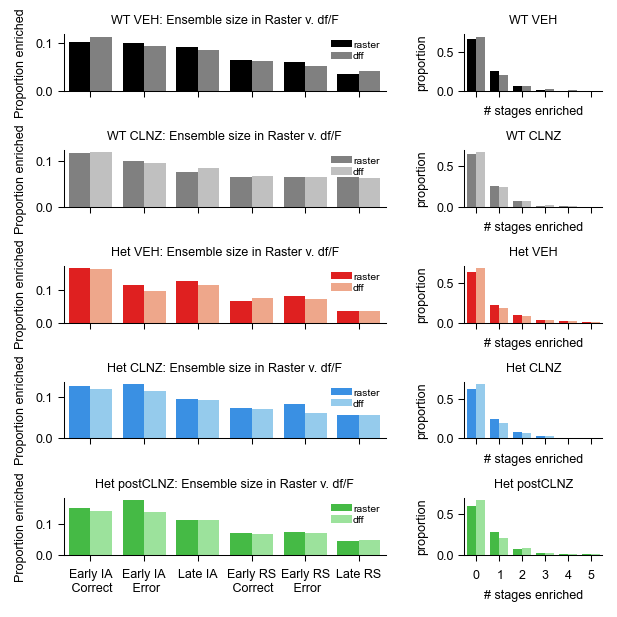

In [129]:
# combine raster & dff dataframes with a datatype label
combined_enrich = pd.concat([
    geno_mean_enrich.assign(datatype='raster'),
    geno_mean_enrich_dff.assign(datatype='dff')
])
combined_pdf = pd.concat([
    prop_of_cells_enrich_n_stages.assign(datatype='raster'),
    prop_of_cells_enrich_n_stages_dff.assign(datatype='dff')
])

# light named-color variant for each geno color
light_color_list = ['grey', 'silver', 'lightsalmon', 'lightskyblue', 'lightgreen']

fig, axes = plt.subplots(len(geno_order_w_WT_CLNZ), 2, 
                         figsize=(4, 4),
                         layout='constrained', sharex='col',
                           width_ratios = [0.7, 0.3], gridspec_kw = dict(wspace = 0.1) )

for row, geno in enumerate(geno_order_w_WT_CLNZ):
    palette = {'raster': color_list_WT_CLNZ[row], 'dff': light_color_list[row]}

    # --- Col 0: % enriched per stage ---
    ax = axes[row, 0]
    sns.barplot(ax=ax, data=combined_enrich[combined_enrich.geno_day == geno],
                x='phase', y='prop_enriched', hue='datatype', hue_order=['raster', 'dff'],
                order=phase_list_IA_RS_chrono, palette=palette, errorbar=None)
    #ad modification    
    set_ax_title_xlabel_ylabel(ax, {'title': f"{geno}: Ensemble size in Raster v. df/F", 'ylabel': 'Proportion enriched', 'xlabel': None})
    ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels()))
    ax.legend(ncol = 1, frameon= False)
    
    # --- Col 1: PDF of # stages enriched ---
    ax = axes[row, 1]
    sns.barplot(ax=ax, data=combined_pdf[combined_pdf.geno_day == geno],
                x='num_enrich', y='prop_enrich', hue='datatype', hue_order=['raster', 'dff'],
                palette=palette, errorbar=None)
    set_ax_title_xlabel_ylabel(ax, {'title': geno, 'xlabel': '# stages enriched',
                                    'ylabel': 'proportion'})
    ax.get_legend().remove()
    ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))

## save fig
fig_name = "Revision_SUPP_ dff_v_spike_ensemble_size"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='r_1', filetypes_to_save = ['svg','png'],bbox_inches="tight",pad_inches=0)

####  Ensemble % conserved 

In [130]:
merged_enriched_chunks = pd.merge(enriched_spikes,enriched_dff, how = 'inner', on=['subject_name', 'geno_day', unit_ID_col], suffixes=('_dff', '_spikes'))
merged_enriched_chunks.sample()

,,,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes
subject_name,geno_day,neuron_ID,,,,,,,,,,,,
13_8_HET_RS2,Het CLNZ,13_8_HET_RS2-62,0,0.0,0,0,0,0,0,0.0,0,0,0,0


In [131]:
# Cross-tabulation of dff vs spikes enrichment, faceted by geno_day
dff_cols = [c for c in merged_enriched_chunks.columns if c.endswith('_dff')]
base_stages = [c.replace('_dff', '') for c in dff_cols]

summary_rows = []
for stage in base_stages:
    dff_col = f"{stage}_dff"
    spike_col = f"{stage}_spikes"
    pair = merged_enriched_chunks[[dff_col, spike_col]].dropna()
    pair = pair.assign(**{dff_col: pair[dff_col].astype(int), spike_col: pair[spike_col].astype(int)})

    for geno_day, grp in pair.groupby(level='geno_day'):
        n = len(grp)
        ## calculate cosine similarity between dff and spike enrichment vectors for this geno-day X stage
        cosine_sim = np.dot(grp[dff_col], grp[spike_col]) / (np.linalg.norm(grp[dff_col]) * np.linalg.norm(grp[spike_col]))
        both_0    = ((grp[dff_col] == 0) & (grp[spike_col] == 0)).sum()
        dff_only  = ((grp[dff_col] == 1) & (grp[spike_col] == 0)).sum()
        spike_only = ((grp[dff_col] == 0) & (grp[spike_col] == 1)).sum()
        both_1    = ((grp[dff_col] == 1) & (grp[spike_col] == 1)).sum()
        summary_rows.append({
            'stage': stage,
            'geno_day': geno_day,
            'n': n,
            'neither': both_0,
            'dff_only': dff_only,
            'spikes_only': spike_only,
            'both': both_1,
            'cosine_similarity': cosine_sim
        })

crosstab_summary = pd.DataFrame(summary_rows)
# Add percentage columns
for col in ['neither', 'dff_only', 'spikes_only', 'both']:
    crosstab_summary[f'{col}_pct'] = (crosstab_summary[col] / crosstab_summary['n'] * 100).round(1)

display(crosstab_summary)


,stage,geno_day,n,neither,dff_only,spikes_only,both,cosine_similarity,neither_pct,dff_only_pct,spikes_only_pct,both_pct
0,Early_IA_Correct,Het CLNZ,866,711,27,46,82,0.694218,82.1,3.1,5.3,9.5
1,Early_IA_Correct,Het VEH,874,673,28,56,117,0.738718,77.0,3.2,6.4,13.4
2,Early_IA_Correct,Het postCLNZ,937,737,39,59,102,0.676983,78.7,4.2,6.3,10.9
3,Early_IA_Correct,WT CLNZ,1019,848,30,51,90,0.691898,83.2,2.9,5.0,8.8
4,Early_IA_Correct,WT VEH,1080,898,38,73,71,0.566714,83.1,3.5,6.8,6.6
5,Early_IA_Error,Het CLNZ,742,608,28,37,69,0.680472,81.9,3.8,5.0,9.3
6,Early_IA_Error,Het VEH,749,636,24,26,63,0.715955,84.9,3.2,3.5,8.4
7,Early_IA_Error,Het postCLNZ,689,540,31,29,89,0.747926,78.4,4.5,4.2,12.9
8,Early_IA_Error,WT CLNZ,838,720,23,35,60,0.675695,85.9,2.7,4.2,7.2
9,Early_IA_Error,WT VEH,870,751,25,33,61,0.678448,86.3,2.9,3.8,7.0


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


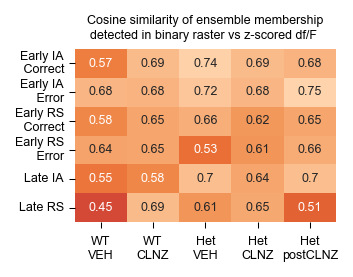

In [132]:
fig, ax = plt.subplots(1,1,figsize =(2.25,1.5))
## plot heatmap of cell overlap 
ensemble_sim = crosstab_summary.pivot(index = 'stage', columns = 'geno_day', values = 'cosine_similarity')
sns.heatmap(ensemble_sim.loc[:,geno_order_w_WT_CLNZ], center = 0, cbar = False, annot = True) 

## set labels
ax.set_yticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_yticklabels()), rotation=0)
ax.set_xticklabels([label.get_text().replace(" ", "\n") for label in ax.get_xticklabels()], rotation=0)
set_labels(ax, label_dict = {'xlabel': None, 'ylabel': {True:  "Ensemble used", False: ""}[comp_count ==0],
                                'title': f"Cosine similarity of ensemble membership\ndetected in binary raster vs z-scored df/F "})

fig_name = "Revision_cosine_sim of dff & raster ensembles"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='r_1', filetypes_to_save = ['svg','png'],bbox_inches="tight",pad_inches=0)


## Rand_permute vs circle ens. size, with FDR

In [133]:
#return_FDR_pvalue_df() is called on DF, which sorts values, find crit value, then check pvalue against that critical value
## multiple corrections functions
def return_FDR_pvalue_df(pval_vec_test_input, pvalue_col_name, FDR_alpha_to_use = 0.05):
    """ perform 2step FDR on p-value vector """ 
    #to : given a vector othat inlclues the combined name + pvalue
    #specify what col this pvalue is within

    critical_value_at_sorted_index = return_critical_value_vector(FDR_alpha_to_use, len(pval_vec_test_input)) #vector where position k = k * alpha value / len of overall vector
    #important- keep ID of position to merge appropriately 
    if type(pval_vec_test_input) is pd.core.series.Series:
        pvals_sorted = pval_vec_test_input.sort_values()
    else:
        pvals_sorted = pval_vec_test_input.sort_values(by = pvalue_col_name)
    pval_below_crit =  pvals_sorted[pvalue_col_name] <= critical_value_at_sorted_index #bool vec: true if pvalue <= crit value at equivalent index
    print(f"np.sum(pval_below_crit) = {np.sum(pval_below_crit)}")
    print(f"pval_below_crit {pval_below_crit}")
    # find max p val for 2 step
    if np.sum(pval_below_crit) > 0:
            max_p_below_crit_val = np.max(pvals_sorted[pval_below_crit]) #the larges p value that still is below critical value
    else:
            max_p_below_crit_val = pd.Series()
            max_p_below_crit_val[pvalue_col_name] = 0
    
    print(max_p_below_crit_val)
    # print(pvals_sorted[pval_below_crit])

    pval_vec_test_input['pval_below_crit'] =pval_below_crit
    pval_vec_test_input['crit_value'] =critical_value_at_sorted_index
    #given the maximum p value that is still below its corresponding crit value, threshold all pvalues
    pval_vec_test_input['is_pval_sig_fdr'] = pval_vec_test_input[pvalue_col_name] <= max_p_below_crit_val[pvalue_col_name]
    return pval_vec_test_input, pvals_sorted[pval_below_crit]

## minimum viable prod:  return correction col, no critical bvalue
def get_significance_multi_correction(pval_col, correction_type, alpha = 0.05, num_unique_comparisons= None):
    '''  
    inputs:    pval_col: numpy array: 
    '''
    #takes FDR or bonf
    if num_unique_comparisons == None: #set default to len of pval_col
        num_unique_comparisons= len(pval_col)
    #returns series of corrections
    if correction_type == "bonf":
        corrected_col =  pval_col<(alpha/num_unique_comparisons)
    if correction_type == "FDR": # create FDR significance vector
        corrected_col, crit_vals = return_fdr_correction_on_pval_vector(pval_col, alpha)
    return corrected_col

#code for FDR comparison on pvalue vector
# Calculate each individual p-value’s Benjamini-Hochberg critical value, using the formula (i/m)Q, where:
#    # i = the individual p-value’s rank,    # m = total number of tests,    # Q = the false discovery rate (a percentage, chosen by you).
def return_fdr_correction_on_pval_vector(input_pval_vec, alpha = 0.05):
    #inputs- input_pval_vec, numpy vecor 
    pvals_sorted = np.sort(input_pval_vec)
    critical_value_at_sorted_index = return_critical_value_vector(alpha, len(input_pval_vec)) #vector where position k = k * alpha value / len of overall vector
    # for sorted position k, find k*alpha/length(vector) which = factor adjustment that will be MULTIPLIED pvalue
    pval_sig_fdr =  pvals_sorted <= critical_value_at_sorted_index

    # now find largest P(k) such that P(k) < critical value
    if np.sum(pval_sig_fdr) > 0:
        max_p_below_crit_val = np.max(pvals_sorted[pval_sig_fdr]) #the larges p value that still is below critical value
    else:
        max_p_below_crit_val = 0
    #this uses original pvale vec, then thresholds
    is_pval_sig_fdr = input_pval_vec <= max_p_below_crit_val # B-H finds largest K such that P <= K
    #all p values below max_p_below_crit_val is significant
    return is_pval_sig_fdr, critical_value_at_sorted_index

#return the critical value
def return_critical_value_vector(input_alpha, vec_len):
        critical_value_at_sorted_index = input_alpha* (np.arange(1,vec_len+1)/vec_len) #vector where position k = k * alpha value / len of overall vector
        return critical_value_at_sorted_index

# #because I want to keep the crit value associated with the p-value, rather than just the sorted crit value, I input as a series
# input_pval_series = test_df[pval_col_name].copy()
# alpha = 0.05
## functio mockup
def perform_BH_FDR_on_pvalue_series(input_pval_series: pd.Series, 
                                    pval_col_name:str =  "percent_shuffle >= real",
                                    alpha:float = 0.05):
    """ Funciton to take pd.Series with p-values, perform 2-step BH FDR and return corrected significance and associ. crit values used
    returns:
    merged_df: pandas df merging original input series with new FDR info"""
    input_pval_series= input_pval_series.to_frame() #change series to frame to allow adding
    sorted_input_pval_df = input_pval_series.sort_values(by = pval_col_name)
    #get critical value vector
    critical_value_at_sorted_index = return_critical_value_vector(alpha, len(input_pval_series)) #vector where position k = k * alpha value / len of overall vector
    print(f"Finding K for up to {len(input_pval_series)} places, with alpha = {alpha}")
    # add critical value to sorted df
    sorted_input_pval_df['critical_val_at_sort_idx'] = critical_value_at_sorted_index
    sorted_input_pval_df['is_sorted_pval_below_crit_val']=  sorted_input_pval_df.apply(lambda x: x[pval_col_name] <= x['critical_val_at_sort_idx'], axis = 1)

    #if at least 1 p-value is < k, find the following:
    if sorted_input_pval_df['is_sorted_pval_below_crit_val'].sum() > 0:
    
    #find maximum p-value that is less than or equal to K (critical value at its index)
        sorted_pval_below_k_bool =   sorted_input_pval_df['is_sorted_pval_below_crit_val']
        #use boolean to index into sorted array, and get largest p-value 
        max_pval_below_crit_val = sorted_input_pval_df.loc[sorted_pval_below_k_bool, pval_col_name].max()
        #threshold ALL pvalues with largest sub-K p-value:
        sorted_input_pval_df['is_pval_below_max_subK_pval'] = sorted_input_pval_df[pval_col_name] <= max_pval_below_crit_val
    
    else: #else, fill in gaps and set all bool sig below FDr to 0
        print(f" FDR results in 0 p-vals < threshold")
        sorted_input_pval_df['is_pval_below_max_subK_pval'] = False
        max_pval_below_crit_val = np.nan
    print(f"max_pval_below_crit_val = {max_pval_below_crit_val}")

    #after everything, re-join on index with input series
    #add sort col
    sorted_input_pval_df['BH_rank_k'] = np.arange(1, len(sorted_input_pval_df) + 1) 
    function_added_cols = ['is_pval_below_max_subK_pval','is_sorted_pval_below_crit_val','critical_val_at_sort_idx','BH_rank_k']
    merged_df = input_pval_series.merge(sorted_input_pval_df[function_added_cols], left_index = True, right_index = True)
    #record max p value used
    merged_df['max_p_below_k']= max_pval_below_crit_val
    # check that you mantained size of series
    assert sorted_input_pval_df.shape[0] == input_pval_series.shape[0]
    return merged_df



#### Import label permuted data

In [134]:
rand_perm_type = 'random_permute'
#map metadata cols added in matlab, to unlabeled cols in csv import
unnamed_var_map = {'Var1_1': 'run_date',
'Var1_2': 'num_shuffles',
'Var1_3': 'threshold_percentile', 
'Var1_4': 'dropped_low_value_peaks',
'Var1_5': 'cutoff_filter',
'Var1_6': 'peak_event_cutoff_percentile',
'name': 'subject_name'}

# import file itself
random_permute_file = data_location / Path(r"matlab_10K_shuff_randperm_ensemble_data\WT_CLNZ_complexTACO- neurons_randperm_activity by task phase_01-Mar-2026.xls")
print(f"Loading randomly permuted shuffles from {random_permute_file} ")
rand_perm_df = pd.read_excel(random_permute_file).replace(-99, np.nan)
rand_perm_df = rand_perm_df.drop(columns = [x for x in rand_perm_df.columns if ('pre' in x) or ('ITI' in x)]) #drop unnamed cols
rand_perm_df = rand_perm_df.rename(columns = unnamed_var_map) #rename unnamed cols to metadata cols
rand_perm_df = rand_perm_df.rename(columns ={c: c.replace("_post_outcome_", "_") for c in rand_perm_df.columns if "post_outcome" in c}) #rename unnamed cols to metadata cols

rand_perm_df['neuron_ID'] = rand_perm_df['subject_name'].astype(str) + "-" + rand_perm_df['neuron_ID'].astype(str) #make unique ID col for merging
annotate_csv(rand_perm_df, 'subject_name')
rand_perm_df.sample()

Loading randomly permuted shuffles from c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\matlab_10K_shuff_randperm_ensemble_data\WT_CLNZ_complexTACO- neurons_randperm_activity by task phase_01-Mar-2026.xls 


,post_outcome_Early_IA_Error,post_outcome_Early_IA_Correct,post_outcome_Late_IA,post_outcome_Early_RS_Error,post_outcome_Early_RS_Correct,post_outcome_Late_RS,pvalue_Early_IA_Error,pvalue_Early_IA_Correct,pvalue_Late_IA,pvalue_Early_RS_Error,...,geno,neuron_ID,peak_dff_threshold_percentile,run_date,num_shuffles,threshold_percentile,dropped_low_value_peaks,cutoff_filter,peak_event_cutoff_percentile,day
1779,NaN,1,0,0,0,0,NaN,0.006,1.0,1.0,...,WT,13_6_WT_RS1-137,1,01-Mar-2026 20:49:41,1000,95,False,bimodality,1,1


#### Perform FDR on random permute shuffled data

In [135]:
id_cols = ['subject_name', 'geno_day', 'geno', 'day', 'neuron_ID','run_date', 'num_shuffles']
#wide_to_long finds stubnames, splits the rest of the col name by sep, and uses piece after stubname as value of new 'j' col
rand_perm_melted = pd.wide_to_long(rand_perm_df,
                                   i = id_cols, 
                                   stubnames = ['post_outcome', 'pvalue', 'threshold_95'], 
                                   suffix = ".+",
                                   sep = "_",
                                   j = 'task_stage')#drop unused metadata cols
rand_perm_melted = rand_perm_melted.drop(
    columns = ['baseline_sig_cells', 'peak_dff_threshold_percentile'] + [v for v in unnamed_var_map.values() if v in rand_perm_melted.columns]).reset_index()
rand_perm_melted

,subject_name,geno_day,geno,day,neuron_ID,run_date,num_shuffles,task_stage,post_outcome,pvalue,threshold_95
0,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_IA_Error,1.0,0.0,0.031667
1,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_IA_Correct,0.0,1.0,0.025833
2,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Late_IA,0.0,1.0,0.024667
3,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_RS_Error,0.0,1.0,0.028333
4,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_RS_Correct,0.0,1.0,0.026667
...,...,...,...,...,...,...,...,...,...,...,...
35761,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_IA_Correct,0.0,1.0,0.008889
35762,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Late_IA,0.0,1.0,0.007667
35763,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_RS_Error,0.0,1.0,0.010000
35764,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_RS_Correct,0.0,1.0,0.008889


In [136]:
test_df = rand_perm_melted
#set FDR params:
pval_col_name = "pvalue"
alpha_FDR = 0.05
#iterate using FDR by subject on task stage
all_fdr_pval = []
all_fdr_pval = []

for s in stage_names:
    for g in geno_order_w_WT_CLNZ:
        print(f"Performing FDR for stage {s} and geno {g}")
        stage_df = test_df.loc[(test_df.task_stage == s) & (test_df.geno_day == g),:]
        input_pval_series = stage_df[pval_col_name]
        print(f" {s} -  matrix shape - {input_pval_series.shape}")
        corr_pval = perform_BH_FDR_on_pvalue_series(input_pval_series, pval_col_name = pval_col_name, alpha = alpha_FDR)
        all_fdr_pval.append(corr_pval)

stage_FDR_df = test_df.merge(pd.concat(all_fdr_pval), left_index = True, right_index = True,suffixes = ("", "_fdr"))
stage_FDR_df

Performing FDR for stage Early_IA_Correct and geno WT VEH
 Early_IA_Correct -  matrix shape - (1350,)
Finding K for up to 1350 places, with alpha = 0.05
max_pval_below_crit_val = 0.014
Performing FDR for stage Early_IA_Correct and geno WT CLNZ
 Early_IA_Correct -  matrix shape - (1246,)
Finding K for up to 1246 places, with alpha = 0.05
max_pval_below_crit_val = 0.012
Performing FDR for stage Early_IA_Correct and geno Het VEH
 Early_IA_Correct -  matrix shape - (1094,)
Finding K for up to 1094 places, with alpha = 0.05
max_pval_below_crit_val = 0.016
Performing FDR for stage Early_IA_Correct and geno Het CLNZ
 Early_IA_Correct -  matrix shape - (1094,)
Finding K for up to 1094 places, with alpha = 0.05
max_pval_below_crit_val = 0.011
Performing FDR for stage Early_IA_Correct and geno Het postCLNZ
 Early_IA_Correct -  matrix shape - (1177,)
Finding K for up to 1177 places, with alpha = 0.05
max_pval_below_crit_val = 0.014
Performing FDR for stage Early_IA_Error and geno WT VEH
 Early_IA

,subject_name,geno_day,geno,day,neuron_ID,run_date,num_shuffles,task_stage,post_outcome,pvalue,threshold_95,pvalue_fdr,is_pval_below_max_subK_pval,is_sorted_pval_below_crit_val,critical_val_at_sort_idx,BH_rank_k,max_p_below_k
0,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_IA_Error,1.0,0.0,0.031667,0.0,True,True,0.000046,1,0.008
1,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_IA_Correct,0.0,1.0,0.025833,1.0,False,False,0.024497,536,0.016
2,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Late_IA,0.0,1.0,0.024667,1.0,False,False,0.022943,502,0.013
3,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_RS_Error,0.0,1.0,0.028333,1.0,False,False,0.021298,466,0.011
4,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_RS_Correct,0.0,1.0,0.026667,1.0,False,False,0.014671,321,0.007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35761,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_IA_Correct,0.0,1.0,0.008889,1.0,False,False,0.050000,1177,0.014
35762,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Late_IA,0.0,1.0,0.007667,1.0,False,False,0.050000,1177,0.009
35763,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_RS_Error,0.0,1.0,0.010000,1.0,False,False,0.050000,1177,0.009
35764,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_RS_Correct,0.0,1.0,0.008889,1.0,False,False,0.050000,1177,0.005


#### Merge circ shuff & label_permute

In [137]:
## import TACO file directly of 10K spike circ. shuffles
matlab_TACO_filename = data_location / Path(r"29-Jan-2026_neurons_ sig enrichment vectors by task stage_10000__shuffles_hour__15\WT_CLNZ_complexTACO- neurons_activity by task phase_30-Jan-2026.xls")
cell_period_active = pd.read_excel(matlab_TACO_filename, na_values=[-99, '-99']).replace(-99, np.nan)

## process/drop unneeded cols 
generic_col_to_drop = [c for c in cell_period_active.columns if any(p in c for p in ('peak', 'ITI', 'cutoff', 'pre_outcome'))]
print(f" dropping cols: {generic_col_to_drop}")
cell_period_active.drop(columns = generic_col_to_drop + ['Var1_4', 'Var1_5', 'Var1_6'], inplace = True)
cell_period_active = cell_period_active.rename(columns = {'name': 'subject_name', 'Var1_1': "Run_end_time", 'Var1_2': "num_shuffles", 'Var1_3':"percentile_cutoff"})
cell_period_active['session'] = cell_period_active['subject_name'].str.split("_").str.get(3)
cell_period_active= cell_period_active.rename(columns ={c: c.replace("_post_outcome_", "_") for c in cell_period_active.columns if "post_outcome" in c}) #rename unnamed cols to metadata cols
## add neuron Id unique col 
cell_col = 'neuron_ID'
cell_period_active['raw_ID'] = cell_period_active[cell_col].astype(str)
cell_period_active[cell_col] = cell_period_active['subject_name'] + '-' + cell_period_active['raw_ID']
annotate_csv(cell_period_active, 'subject_name')
print(cell_period_active.info())
cell_period_active.head()


 dropping cols: ['pre_outcome_Early_IA_Error', 'pre_outcome_Early_IA_Correct', 'pre_outcome_Late_IA', 'pre_outcome_Early_RS_Error', 'pre_outcome_Early_RS_Correct', 'pre_outcome_Late_RS', 'ITI_Early_IA_Error', 'ITI_Early_IA_Correct', 'ITI_Late_IA', 'ITI_Early_RS_Error', 'ITI_Early_RS_Correct', 'ITI_Late_RS', 'pvalue_pre_outcome_Early_IA_Error', 'pvalue_pre_outcome_Early_IA_Correct', 'pvalue_pre_outcome_Late_IA', 'pvalue_pre_outcome_Early_RS_Error', 'pvalue_pre_outcome_Early_RS_Correct', 'pvalue_pre_outcome_Late_RS', 'pvalue_ITI_Early_IA_Error', 'pvalue_ITI_Early_IA_Correct', 'pvalue_ITI_Late_IA', 'pvalue_ITI_Early_RS_Error', 'pvalue_ITI_Early_RS_Correct', 'pvalue_ITI_Late_RS', 'threshold_95_pre_outcome_Early_IA_Error', 'threshold_95_pre_outcome_Early_IA_Correct', 'threshold_95_pre_outcome_Late_IA', 'threshold_95_pre_outcome_Early_RS_Error', 'threshold_95_pre_outcome_Early_RS_Correct', 'threshold_95_pre_outcome_Late_RS', 'threshold_95_ITI_Early_IA_Error', 'threshold_95_ITI_Early_IA_Corre

,post_outcome_Early_IA_Error,post_outcome_Early_IA_Correct,post_outcome_Late_IA,post_outcome_Early_RS_Error,post_outcome_Early_RS_Correct,post_outcome_Late_RS,pvalue_Early_IA_Error,pvalue_Early_IA_Correct,pvalue_Late_IA,pvalue_Early_RS_Error,...,subject_name,geno_day,geno,neuron_ID,Run_end_time,num_shuffles,percentile_cutoff,session,raw_ID,day
0,1.0,0,0,0,0,0,0.0004,1.0000,1.0000,1.0000,...,10_3_HET_RS1,Het VEH,HET,10_3_HET_RS1-1,30-Jan-2026 17:20:28,10000,95,RS1,1,1
1,0.0,0,0,0,0,0,1.0000,1.0000,1.0000,1.0000,...,10_3_HET_RS1,Het VEH,HET,10_3_HET_RS1-2,30-Jan-2026 17:20:28,10000,95,RS1,2,1
2,1.0,0,0,0,0,0,0.0110,1.0000,0.1441,0.2461,...,10_3_HET_RS1,Het VEH,HET,10_3_HET_RS1-3,30-Jan-2026 17:20:28,10000,95,RS1,3,1
3,0.0,0,0,1,0,0,1.0000,1.0000,0.1661,0.0406,...,10_3_HET_RS1,Het VEH,HET,10_3_HET_RS1-4,30-Jan-2026 17:20:28,10000,95,RS1,4,1
4,0.0,0,0,0,0,0,1.0000,0.1009,0.4649,0.0815,...,10_3_HET_RS1,Het VEH,HET,10_3_HET_RS1-5,30-Jan-2026 17:20:28,10000,95,RS1,5,1


In [138]:
## import real data and use list of neuron IDs contained in df to filter out inactive TACO neurons:
trial_df_filename = data_location /  r"matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet" # new matlab made 10k shuffle file 
# trial_df_filename = data_location /  f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
trial_tseries_df_norm

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,section,subject_name,session,raw_ID,day,...,pvalue_post_outcome_Late_RS,Run_end_time,num_shuffles,any_enrichment,enriched_in_phase,normalized,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial
0,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-1,post_outcome,10_3_HET_RS1,RS1,1,1,...,1.0000,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.0000,False
2,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-3,post_outcome,10_3_HET_RS1,RS1,3,1,...,0.3656,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.0000,False
3,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-4,post_outcome,10_3_HET_RS1,RS1,4,1,...,1.0000,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.0000,False
4,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-5,post_outcome,10_3_HET_RS1,RS1,5,1,...,1.0000,30-Jan-2026 17:20:28,10000,0.0,False,none,1.0,all_frames,0.2900,True
5,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-6,post_outcome,10_3_HET_RS1,RS1,6,1,...,0.1980,30-Jan-2026 17:20:28,10000,0.0,False,none,1.0,all_frames,0.0000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116370,Late_RS,RS,Correct,38,9_3_HET_RS3-209,post_outcome,9_3_HET_RS3,RS3,209,3,...,0.4277,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.0150,True
116373,Late_RS,RS,Correct,38,9_3_HET_RS3-212,post_outcome,9_3_HET_RS3,RS3,212,3,...,0.4392,30-Jan-2026 17:20:28,10000,2.0,False,none,1.0,all_frames,0.0225,True
116374,Late_RS,RS,Correct,38,9_3_HET_RS3-213,post_outcome,9_3_HET_RS3,RS3,213,3,...,1.0000,30-Jan-2026 17:20:28,10000,0.0,False,none,1.0,all_frames,0.0000,False
116375,Late_RS,RS,Correct,38,9_3_HET_RS3-214,post_outcome,9_3_HET_RS3,RS3,214,3,...,0.0483,30-Jan-2026 17:20:28,10000,1.0,True,none,1.0,all_frames,0.1500,True


In [139]:
cells_in_spike_df = trial_tseries_df_norm.neuron_ID.unique()
print(f"Number of unique neurons in spike timeseries df: {len(cells_in_spike_df)}")
## filter TACO df to only include neurons present in real data
filtered_cell_period_active = cell_period_active[cell_period_active[cell_col].isin(cells_in_spike_df)].copy()
print(f"Number of neurons in TACO df after filtering to those present in real data: {filtered_cell_period_active.shape[0]}")
filtered_cell_period_active.sample()

Number of unique neurons in spike timeseries df: 4776
Number of neurons in TACO df after filtering to those present in real data: 4776


,post_outcome_Early_IA_Error,post_outcome_Early_IA_Correct,post_outcome_Late_IA,post_outcome_Early_RS_Error,post_outcome_Early_RS_Correct,post_outcome_Late_RS,pvalue_Early_IA_Error,pvalue_Early_IA_Correct,pvalue_Late_IA,pvalue_Early_RS_Error,...,subject_name,geno_day,geno,neuron_ID,Run_end_time,num_shuffles,percentile_cutoff,session,raw_ID,day
3593,0.0,0,0,0,0,0,1.0,1.0,1.0,1.0,...,15_1_HET_RS3,Het postCLNZ,HET,15_1_HET_RS3-66,30-Jan-2026 17:20:28,10000,95,RS3,66,3


In [140]:
id_cols = ['subject_name', 'geno_day', unit_ID_col]
#wide_to_long finds stubnames, splits the rest of the col name by sep, and uses piece after stubname as value of new 'j' col
circ_shuf_melt = pd.wide_to_long(filtered_cell_period_active,
                                   i = id_cols, 
                                   stubnames = ['post_outcome', 'pvalue', 'threshold_95'], 
                                   suffix = ".+",
                                   sep = "_",
                                   j = 'task_stage')#drop unused metadata cols
circ_shuf_melt = circ_shuf_melt.drop(columns = ['baseline_sig_cells'] + [v for v in unnamed_var_map.values() if v in circ_shuf_melt.columns]).reset_index()
circ_shuf_melt

,subject_name,geno_day,neuron_ID,task_stage,raw_ID,Run_end_time,day,geno,percentile_cutoff,session,post_outcome,pvalue,threshold_95
0,10_3_HET_RS1,Het VEH,10_3_HET_RS1-1,Early_IA_Error,1,30-Jan-2026 17:20:28,1,HET,95,RS1,1.0,0.0004,0.173333
1,10_3_HET_RS1,Het VEH,10_3_HET_RS1-1,Early_IA_Correct,1,30-Jan-2026 17:20:28,1,HET,95,RS1,0.0,1.0000,0.096667
2,10_3_HET_RS1,Het VEH,10_3_HET_RS1-1,Late_IA,1,30-Jan-2026 17:20:28,1,HET,95,RS1,0.0,1.0000,0.096000
3,10_3_HET_RS1,Het VEH,10_3_HET_RS1-1,Early_RS_Error,1,30-Jan-2026 17:20:28,1,HET,95,RS1,0.0,1.0000,0.150833
4,10_3_HET_RS1,Het VEH,10_3_HET_RS1-1,Early_RS_Correct,1,30-Jan-2026 17:20:28,1,HET,95,RS1,0.0,1.0000,0.126667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28651,9_3_HET_RS3,Het postCLNZ,9_3_HET_RS3-215,Early_IA_Correct,215,30-Jan-2026 17:20:28,3,HET,95,RS3,0.0,1.0000,0.029444
28652,9_3_HET_RS3,Het postCLNZ,9_3_HET_RS3-215,Late_IA,215,30-Jan-2026 17:20:28,3,HET,95,RS3,0.0,1.0000,0.023333
28653,9_3_HET_RS3,Het postCLNZ,9_3_HET_RS3-215,Early_RS_Error,215,30-Jan-2026 17:20:28,3,HET,95,RS3,0.0,1.0000,0.033333
28654,9_3_HET_RS3,Het postCLNZ,9_3_HET_RS3-215,Early_RS_Correct,215,30-Jan-2026 17:20:28,3,HET,95,RS3,0.0,1.0000,0.030000


In [141]:
stage_FDR_df

,subject_name,geno_day,geno,day,neuron_ID,run_date,num_shuffles,task_stage,post_outcome,pvalue,threshold_95,pvalue_fdr,is_pval_below_max_subK_pval,is_sorted_pval_below_crit_val,critical_val_at_sort_idx,BH_rank_k,max_p_below_k
0,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_IA_Error,1.0,0.0,0.031667,0.0,True,True,0.000046,1,0.008
1,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_IA_Correct,0.0,1.0,0.025833,1.0,False,False,0.024497,536,0.016
2,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Late_IA,0.0,1.0,0.024667,1.0,False,False,0.022943,502,0.013
3,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_RS_Error,0.0,1.0,0.028333,1.0,False,False,0.021298,466,0.011
4,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_RS_Correct,0.0,1.0,0.026667,1.0,False,False,0.014671,321,0.007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35761,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_IA_Correct,0.0,1.0,0.008889,1.0,False,False,0.050000,1177,0.014
35762,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Late_IA,0.0,1.0,0.007667,1.0,False,False,0.050000,1177,0.009
35763,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_RS_Error,0.0,1.0,0.010000,1.0,False,False,0.050000,1177,0.009
35764,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_RS_Correct,0.0,1.0,0.008889,1.0,False,False,0.050000,1177,0.005


In [142]:
from matplotlib_venn import venn2
use_custom_venn_colors = True
from ensemble_overlap import get_geno_stage_overlap_crosstab, plot_ensemble_venn, plot_save_ensemble_overlap_fig, compute_ensemble_overlap_chi2

## compute overlap statistics
all_ensemble_pairs =  [['Early_IA_Correct', 'Early_RS_Correct'],
                        ['Early_IA_Error', 'Early_RS_Error'], 
                        ['Early_IA_Correct', 'Late_IA'],
                         ['Late_IA','Early_RS_Correct']]
overlap_tab = compute_ensemble_overlap_chi2(unit_mean_tseries, all_ensemble_pairs, geno_order_w_WT_CLNZ, stage_names)
overlap_tab.tail()

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Late_IA,Early_RS_Correct,24,1080,0.022222,2.222222,75,46,"[[935, 75], [46, 24]]",53.541789,0.0,1,"[[917.4166666666666, 92.58333333333333], [63.5..."
1,WT CLNZ,Late_IA,Early_RS_Correct,11,1019,0.010795,1.079490,66,54,"[[888, 66], [54, 11]]",7.346526,0.006719,1,"[[881.9116781157998, 72.0883218842002], [60.08..."
2,Het VEH,Late_IA,Early_RS_Correct,26,874,0.029748,2.974828,84,32,"[[732, 84], [32, 26]]",55.601153,0.0,1,"[[713.2997711670481, 102.70022883295195], [50...."
3,Het CLNZ,Late_IA,Early_RS_Correct,20,866,0.023095,2.309469,62,43,"[[741, 62], [43, 20]]",36.581475,0.0,1,"[[726.9653579676674, 76.03464203233257], [57.0..."
4,Het postCLNZ,Late_IA,Early_RS_Correct,27,937,0.028815,2.881537,78,38,"[[794, 78], [38, 27]]",61.349001,0.0,1,"[[774.2838847385273, 97.71611526147278], [57.7..."


In [143]:
## set merge params
value_cols = ['post_outcome','pvalue','threshold_95']
id_cols = ['subject_name', unit_ID_col, 'geno_day', 'task_stage']
fdr_cols = ['pvalue_fdr', 'is_pval_below_max_subK_pval', 'is_sorted_pval_below_crit_val', 'critical_val_at_sort_idx', 'BH_rank_k', 'max_p_below_k']
## perform merge
ens_circ_vs_rand_perm = stage_FDR_df.loc[:, id_cols + value_cols + fdr_cols].merge(circ_shuf_melt.loc[:, id_cols + value_cols], on = id_cols, suffixes = ("_rand_perm", "_circ_shuff"))
ens_circ_vs_rand_perm =ens_circ_vs_rand_perm.rename(columns = {c: c.replace("post_outcome_", "enriched_") for c in ens_circ_vs_rand_perm.columns if "post_outcome" in c})


## possible change: add smoothed p-value (m + 1)/ (n + 1) to avoid 0 p-values, which cause issues with log scale plotting
# ens_circ_vs_rand_perm['smoothed_pvalue'] = (ens_circ_vs_rand_perm['pvalue'] + 1) / (ens_circ_vs_rand_perm['num_shuffles'] + 1)  
ens_circ_vs_rand_perm 

,subject_name,neuron_ID,geno_day,task_stage,enriched_rand_perm,pvalue_rand_perm,threshold_95_rand_perm,pvalue_fdr,is_pval_below_max_subK_pval,is_sorted_pval_below_crit_val,critical_val_at_sort_idx,BH_rank_k,max_p_below_k,enriched_circ_shuff,pvalue_circ_shuff,threshold_95_circ_shuff
0,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Error,1.0,0.0,0.031667,0.0,True,True,0.000046,1,0.008,1.0,0.0004,0.173333
1,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Correct,0.0,1.0,0.025833,1.0,False,False,0.024497,536,0.016,0.0,1.0000,0.096667
2,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Late_IA,0.0,1.0,0.024667,1.0,False,False,0.022943,502,0.013,0.0,1.0000,0.096000
3,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Error,0.0,1.0,0.028333,1.0,False,False,0.021298,466,0.011,0.0,1.0000,0.150833
4,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Correct,0.0,1.0,0.026667,1.0,False,False,0.014671,321,0.007,0.0,1.0000,0.126667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28651,9_3_HET_RS3,9_3_HET_RS3-215,Het postCLNZ,Early_IA_Correct,0.0,1.0,0.008889,1.0,False,False,0.050000,1177,0.014,0.0,1.0000,0.029444
28652,9_3_HET_RS3,9_3_HET_RS3-215,Het postCLNZ,Late_IA,0.0,1.0,0.007667,1.0,False,False,0.050000,1177,0.009,0.0,1.0000,0.023333
28653,9_3_HET_RS3,9_3_HET_RS3-215,Het postCLNZ,Early_RS_Error,0.0,1.0,0.010000,1.0,False,False,0.050000,1177,0.009,0.0,1.0000,0.033333
28654,9_3_HET_RS3,9_3_HET_RS3-215,Het postCLNZ,Early_RS_Correct,0.0,1.0,0.008889,1.0,False,False,0.050000,1177,0.005,0.0,1.0000,0.030000


#### Plot circ vs random shuffle of ensemble enrichment


In [144]:
#given a joined dataframe, plot as a barplot to compare 
# Reshape to long format for seaborn
plot_df = ens_circ_vs_rand_perm.melt(id_vars=['task_stage', 'subject_name', 'geno_day'],
                                    value_vars=['enriched_rand_perm', 'enriched_circ_shuff', 'is_pval_below_max_subK_pval'],
                                    var_name='correction',value_name='is_enriched')

plot_df['correction'] = plot_df['correction'].map({'enriched_rand_perm': 'Label-permute (p<0.05)',
                                                    'is_pval_below_max_subK_pval': 'Label-permute (FDR-corrected p <0.05)',
                                                    'enriched_circ_shuff': 'circle-shuffle (p<0.05)'})
plot_df


,task_stage,subject_name,geno_day,correction,is_enriched
0,Early_IA_Error,10_3_HET_RS1,Het VEH,Label-permute (p<0.05),1.0
1,Early_IA_Correct,10_3_HET_RS1,Het VEH,Label-permute (p<0.05),0.0
2,Late_IA,10_3_HET_RS1,Het VEH,Label-permute (p<0.05),0.0
3,Early_RS_Error,10_3_HET_RS1,Het VEH,Label-permute (p<0.05),0.0
4,Early_RS_Correct,10_3_HET_RS1,Het VEH,Label-permute (p<0.05),0.0
...,...,...,...,...,...
85963,Early_IA_Correct,9_3_HET_RS3,Het postCLNZ,Label-permute (FDR-corrected p <0.05),0.0
85964,Late_IA,9_3_HET_RS3,Het postCLNZ,Label-permute (FDR-corrected p <0.05),0.0
85965,Early_RS_Error,9_3_HET_RS3,Het postCLNZ,Label-permute (FDR-corrected p <0.05),0.0
85966,Early_RS_Correct,9_3_HET_RS3,Het postCLNZ,Label-permute (FDR-corrected p <0.05),0.0


In [145]:

# Per-subject percentages
subj_pct = plot_df.groupby(['task_stage', 'geno_day', 'subject_name', 'correction'])['is_enriched'].mean() * 100
subj_pct = subj_pct.reset_index(name='pct_enriched')
subj_pct


,task_stage,geno_day,subject_name,correction,pct_enriched
0,Early_IA_Correct,Het CLNZ,10_3_HET_RS2,Label-permute (FDR-corrected p <0.05),44.354839
1,Early_IA_Correct,Het CLNZ,10_3_HET_RS2,Label-permute (p<0.05),45.16129
2,Early_IA_Correct,Het CLNZ,10_3_HET_RS2,circle-shuffle (p<0.05),16.935484
3,Early_IA_Correct,Het CLNZ,13_3_HET_RS2,Label-permute (FDR-corrected p <0.05),27.358491
4,Early_IA_Correct,Het CLNZ,13_3_HET_RS2,Label-permute (p<0.05),28.301887
...,...,...,...,...,...
625,Late_RS,WT VEH,7_4_WT_RS1,Label-permute (p<0.05),17.5
626,Late_RS,WT VEH,7_4_WT_RS1,circle-shuffle (p<0.05),10.0
627,Late_RS,WT VEH,7_5_WT_RS1,Label-permute (FDR-corrected p <0.05),25.324675
628,Late_RS,WT VEH,7_5_WT_RS1,Label-permute (p<0.05),29.220779


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


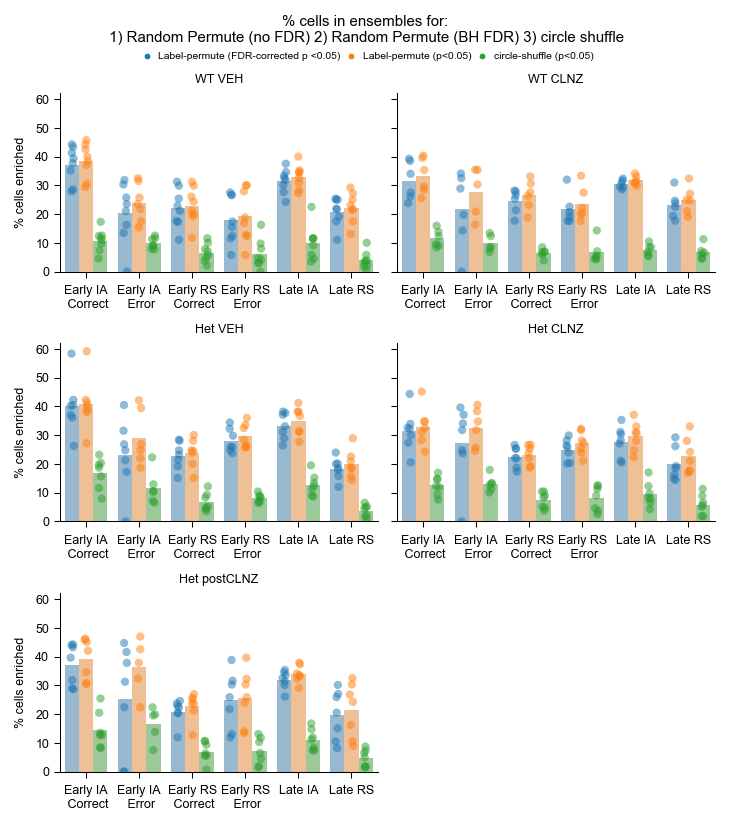

In [146]:

# Plot comparison
fig, axes = plt.subplots(3, 2, figsize=(4.75, 5), sharey = True, layout = 'constrained')
#3 facet by geno

y_val = 'pct_enriched'
x_val = 'task_stage'

#facet by geno_day
for g, geno in enumerate(geno_order_w_WT_CLNZ):
    ax = axes.flat[g]
    sns.stripplot(data=subj_pct[subj_pct['geno_day']==geno], x=x_val, y=y_val, hue='correction', ax=ax, dodge=True,  alpha=0.5, size=4, legend=g == 0)
    if g == 0:
        handles, labels = ax.get_legend_handles_labels() 

    sns.barplot(data=subj_pct[subj_pct['geno_day']==geno], x=x_val, y=y_val, hue='correction', ax=ax, alpha=0.5, errorbar=None)
    ax.get_legend().remove()
    #plot distribution of points w stripplot
    # set ax adjustment
    set_labels(ax, label_dict = {'xlabel': None, 'ylabel': r'% cells enriched', 'title': geno})
    ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels()))
    #if first element, move legend upwards
axes.flat[5].axis('off')

suptitle = f"% cells in ensembles for:\n 1) Random Permute (no FDR) 2) Random Permute (BH FDR) 3) circle shuffle"
fig.suptitle(suptitle, y = 1.07)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03),ncol=len(labels),title=None , frameon=False)

## save fig
fig_name = "Revision_SUPP_ dff_v_spike_ensemble_size_comparison_to_circ_shuff"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='r_1', filetypes_to_save = ['svg','png'],bbox_inches="tight",pad_inches=0)


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


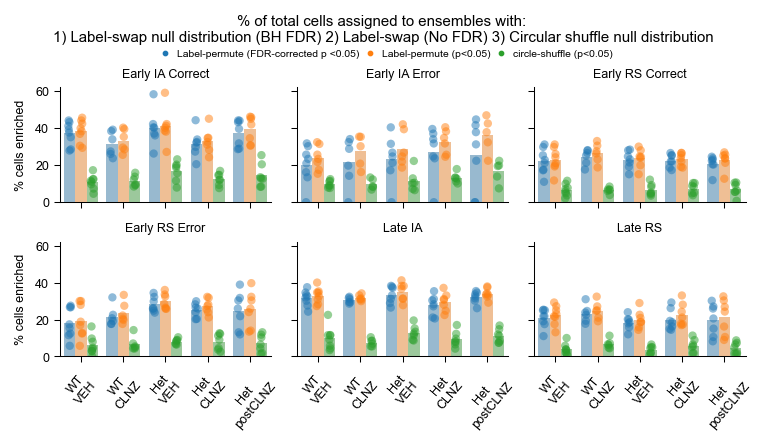

In [147]:
## plot with tiling by stage
fig, axes = plt.subplots(2, 3, figsize=(5, 2.5), sharey = True, sharex = "col", layout = 'constrained', gridspec_kw= {'wspace':0.0})
#3 facet by geno
y_val = 'pct_enriched'
x_val = 'geno_day'

#facet by geno_day
for g, stage in enumerate(stage_names):
    ax = axes.flat[g]
    plot_data = {'data':subj_pct[subj_pct['task_stage']==stage], 'x': x_val, 'y': y_val, 'hue': 'correction'}
    
    #plot distribution of points w stripplot
    sns.stripplot(**plot_data, ax=ax, dodge=True,  alpha=0.5, size=4, legend=g == 0, order = geno_order_w_WT_CLNZ)
    if g == 0:
        handles, labels = ax.get_legend_handles_labels() 
    
    #plot mean values with barplot
    sns.barplot(**plot_data, ax=ax, alpha=0.5, errorbar=None, order=geno_order_w_WT_CLNZ)
    ax.get_legend().remove()
    set_labels(ax, label_dict = {'xlabel': None, 'ylabel': r'% cells enriched', 'title': f"{stage.replace('_', ' ')}"})
    ax.set_xticklabels([x.get_text().replace(' ', '\n') for x in ax.get_xticklabels()], rotation = 50)

suptitle = f"% of total cells assigned to ensembles with: \n1) Label-swap null distribution (BH FDR) 2) Label-swap (No FDR) 3) Circular shuffle null distribution"
fig.suptitle(suptitle, y = 1.125)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),ncol=len(labels),title=None , frameon=False)

## save fig
fig_name = "SUPP_ dff_v_spike_ensemble_size_in_circ_shuff_stageFacet"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='r_1', filetypes_to_save = ['svg','png'],bbox_inches="tight",pad_inches=0)


## Compare Ensemble overlap- rand_perm vs circle 

#### Import overlap functions

In [148]:
from matplotlib_venn import venn2
use_custom_venn_colors = True
from ensemble_overlap import get_geno_stage_overlap_crosstab, plot_ensemble_venn, plot_save_ensemble_overlap_fig, compute_ensemble_overlap_chi2, make_premade_comparison_pvalue_df, update_posthoc_pvalues

## compute overlap statistics
all_ensemble_pairs =  [['Early_IA_Correct', 'Early_RS_Correct'],
                        ['Early_IA_Error', 'Early_RS_Error'], 
                        ['Early_IA_Correct', 'Late_IA'],
                         ['Late_IA','Early_RS_Correct']]
overlap_spikes = compute_ensemble_overlap_chi2(unit_mean_tseries, all_ensemble_pairs, geno_order_w_WT_CLNZ, stage_names)
overlap_spikes.tail()

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Late_IA,Early_RS_Correct,24,1080,0.022222,2.222222,75,46,"[[935, 75], [46, 24]]",53.541789,0.0,1,"[[917.4166666666666, 92.58333333333333], [63.5..."
1,WT CLNZ,Late_IA,Early_RS_Correct,11,1019,0.010795,1.079490,66,54,"[[888, 66], [54, 11]]",7.346526,0.006719,1,"[[881.9116781157998, 72.0883218842002], [60.08..."
2,Het VEH,Late_IA,Early_RS_Correct,26,874,0.029748,2.974828,84,32,"[[732, 84], [32, 26]]",55.601153,0.0,1,"[[713.2997711670481, 102.70022883295195], [50...."
3,Het CLNZ,Late_IA,Early_RS_Correct,20,866,0.023095,2.309469,62,43,"[[741, 62], [43, 20]]",36.581475,0.0,1,"[[726.9653579676674, 76.03464203233257], [57.0..."
4,Het postCLNZ,Late_IA,Early_RS_Correct,27,937,0.028815,2.881537,78,38,"[[794, 78], [38, 27]]",61.349001,0.0,1,"[[774.2838847385273, 97.71611526147278], [57.7..."


In [149]:
## compute overlap stats for dff data
overlap_dff = compute_ensemble_overlap_chi2(unit_mean_tseries_dff, all_ensemble_pairs, geno_order_w_WT_CLNZ, stage_names)
overlap_dff.tail()

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Late_IA,Early_RS_Correct,28,1350,0.020741,2.074074,87,57,"[[1178, 87], [57, 28]]",66.126294,0.0,1,"[[1157.2407407407406, 107.75925925925925], [77..."
1,WT CLNZ,Late_IA,Early_RS_Correct,18,1246,0.014446,1.444623,88,65,"[[1075, 88], [65, 18]]",18.071899,0.000021,1,"[[1064.0609951845906, 98.9390048154093], [75.9..."
2,Het VEH,Late_IA,Early_RS_Correct,41,1094,0.037477,3.747715,85,41,"[[927, 85], [41, 41]]",124.765923,0.0,1,"[[895.4442413162706, 116.55575868372944], [72...."
3,Het CLNZ,Late_IA,Early_RS_Correct,32,1094,0.029250,2.925046,69,46,"[[947, 69], [46, 32]]",97.26719,0.0,1,"[[922.2010968921389, 93.79890310786107], [70.7..."
4,Het postCLNZ,Late_IA,Early_RS_Correct,40,1177,0.033985,3.398471,90,37,"[[1010, 90], [37, 40]]",135.877764,0.0,1,"[[978.5046728971963, 121.49532710280374], [68...."


Saved 2_s_DFF revision Supplement- VEH v CLNZ for Het & WT- ensemble proportion overlap_ensemble chisquared_20_Aug_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_DFF revision Supplement- VEH v CLNZ for Het & WT- ensemble proportion overlap_ensemble chi test_20_Aug_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


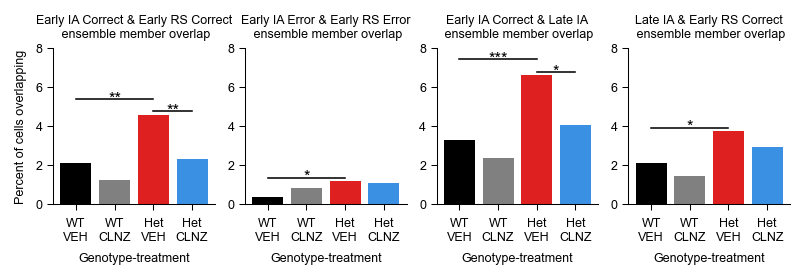

In [150]:
#decide genoplot to amke 
geno_to_plot = ["WT VEH", "WT CLNZ", "Het VEH", "Het CLNZ"]
compare_HET_v_CLNZ_in_WT_VEH= [("WT VEH", "WT CLNZ"), ("Het VEH", "Het CLNZ"), ("WT VEH", "Het VEH")]
sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ")]
fig,ax_array = plt.subplots(1,len(all_ensemble_pairs), figsize = (5.25,1.75), layout = 'constrained')
posthoc_df_list = []
ylim_list = [8,8, 8, 8]
## iterate over all wt clnz comparisons
for e, ensemble_to_plot in enumerate(all_ensemble_pairs):
    ax= ax_array.flat[e]
    comparison_mask = (overlap_dff.set_1_name == ensemble_to_plot[0]).values & (overlap_dff.set_2_name == ensemble_to_plot[1]).values
    ensemble_df = overlap_dff.loc[comparison_mask,:]
    plot_df = ensemble_df.loc[ensemble_df.geno_day.isin(geno_to_plot),:]
    plot_params = dict( data =plot_df, x = 'geno_day',y = 'percent_total_overlap',dodge = False,  hue = 'geno_day', hue_order = geno_to_plot, order = geno_to_plot, palette = color_list_WT_CLNZ)
    
    sc= sns.barplot(ax=ax,**plot_params)
    ax_title= f"{' & '.join([x.replace('_', ' ') for x in ensemble_to_plot])}\n ensemble member overlap"
    ylabel = {True:  "Percent of cells overlapping", False: None}
    set_labels(ax, label_dict = dict(title = ax_title, xlabel= "Genotype-treatment", ylabel = ylabel[e ==0], ylim = [0,ylim_list[e]],  legend_false = True))
    
    ##posthoc annot  
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, sc, compare_HET_v_CLNZ_in_WT_VEH,test_name = 'none',ax_var_is_hue = True,
                                                               detect_error_bar=False,plot_type= 'barplot') # plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:])
    chi_res = [chi2_contingency(plot_df.set_index('geno_day').loc[group,['total_overlap', 'n_total']]) for group in compare_HET_v_CLNZ_in_WT_VEH]
    ## combine into new format
    real_pvalues  = make_premade_comparison_pvalue_df(compare_HET_v_CLNZ_in_WT_VEH, [x.pvalue for x in chi_res])
    posthoc_df= update_posthoc_pvalues(posthoc_df, comparison_pvalues = real_pvalues)    ## make table with precomputed comparison p-value for overwrite  
    posthoc_df.loc[:,'category_compared_within'] = "_x_".join(ensemble_to_plot)
    posthoc_df.stat_result  = [[x.statistic, x.pvalue] for x in chi_res]
    posthoc_df.loc[:,'test_name'] = "chi_squared"
    posthoc_df_list.append(posthoc_df)
    plot_sig_bars_w_comp_df_tight(ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:],tight_offset = 0.02,offset_constant=0.015)
    ax.set_xticklabels([x.get_text().replace(" ", "\n") for x in ax.get_xticklabels()])
## save it
posthoc_df = pd.concat(posthoc_df_list)
fig_name = f"DFF revision Supplement- VEH v CLNZ for Het & WT- ensemble proportion overlap"
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="2_s",fig_name,  csv_folder_most_recent, None, csv_suffix="ensemble chisquared",txt_suffix="ensemble chi test")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='r_1', filetypes_to_save = ['png', 'svg'],bbox_inches="tight",pad_inches=0)

## Reviewer analysis: activity-matched control quality
For each activity-matched control population, a two-sample t-test compared its mean-activity distribution to the ensemble's. The p-value was recorded per iteration but **not** used to reject or re-draw matches (the `while p_value < 0.05` gate is disabled). Here we quantify how often the matched control was statistically indistinguishable from the ensemble (p > 0.05).

In [151]:
## Quantify activity-match quality from stored per-iteration t-tests
## Each activity-matched control is built per enriched group, per geno_day -> summarize at that grain
activity_match_file = (results_location
    / "figure_5_prep_mid_decoding figures_post_outcome_activity_25_Mar_2026"
    / "Decode (Activity Match CCGP) 1000 iter post_outcome_activity 25_Mar_2026.parquet")
am_df = pd.read_parquet(activity_match_file)

def summarize_match_quality(df, **labels):
    """Summarize ensemble-vs-matched-control t-test outcomes for a subset of comparisons."""
    p = df['p_value'].dropna()
    return {**labels,
        'n_ttest_comparisons': len(p),
        'n_pseudopop_iterations': df['pseudopop_run_num'].nunique(),
        'frac_activity_indistinguishable_p_gt_0.05': (p > 0.05).mean(),
        'frac_activity_differs_p_lt_0.05': (p < 0.05).mean(),
        'frac_activity_differs_p_lt_0.01': (p < 0.01).mean(),
        'median_ttest_p_value': p.median(),
        'min_ttest_p_value': p.min(),
    }

# Grand total, then one row per (enriched_group x geno_day) -- the grain each control was matched at
records = [summarize_match_quality(am_df, enriched_group='ALL', geno_day='ALL')]
for (enriched_group, geno_day), sub_df in am_df.groupby(['enriched_group', 'geno_day']):
    records.append(summarize_match_quality(sub_df, enriched_group=enriched_group, geno_day=geno_day))

activity_match_quality_df = pd.DataFrame.from_records(records)
activity_match_quality_df

,enriched_group,geno_day,n_ttest_comparisons,n_pseudopop_iterations,frac_activity_indistinguishable_p_gt_0.05,frac_activity_differs_p_lt_0.05,frac_activity_differs_p_lt_0.01,median_ttest_p_value,min_ttest_p_value
0,ALL,ALL,120000,1000,0.805458,0.194542,0.161942,0.889241,4.663287e-18
1,Early_IA_Correct,Het CLNZ,4000,1000,0.750000,0.250000,0.250000,0.726705,1.602179e-05
2,Early_IA_Correct,Het VEH,4000,1000,0.500000,0.500000,0.500000,0.241505,4.663287e-18
3,Early_IA_Correct,Het postCLNZ,4000,1000,0.750000,0.250000,0.250000,0.323503,3.486753e-11
4,Early_IA_Correct,WT CLNZ,4000,1000,0.727750,0.272250,0.250000,0.448275,5.563864e-06
5,Early_IA_Correct,WT VEH,4000,1000,0.750000,0.250000,0.249750,0.853460,1.874593e-04
6,Early_IA_Error,Het CLNZ,4000,1000,0.998250,0.001750,0.000000,0.567683,3.750225e-02
7,Early_IA_Error,Het VEH,4000,1000,1.000000,0.000000,0.000000,0.817875,1.398383e-01
8,Early_IA_Error,Het postCLNZ,4000,1000,0.500000,0.500000,0.397750,0.455194,3.793147e-06
9,Early_IA_Error,WT CLNZ,4000,1000,0.911500,0.088500,0.000000,0.529966,2.355869e-02


## Reviewer analysis: single mouse CCGP
Cross-condition generalization decoded **within each mouse** instead of pooling cells into a
cross-subject pseudopopulation. Each mouse's own enriched cells are bootstrapped on their own,
so a decoder never sees cells from more than one recording.

Plot aesthetics and panel structure follow the pooled CCGP panels (Figures 3B / 4B) in
`Revisions- Fig 3-7 & Sup Fig 2 SVM v5_activity_match.ipynb`.

Two differences from the pooled panels, both forced by the data:
- **One point per mouse.** The 1000 bootstraps are averaged within a mouse first, so the error
  bars show spread *between mice*, not between bootstraps. Plotting raw bootstrap rows would put
  n in the hundreds of thousands and make every posthoc test significant by construction.
- **No null band.** The single-mouse run has no label-permuted counterpart, so these use the
  plain CCGP layout rather than the `_w_null` variant.


In [152]:
#### Load single mouse CCGP results and average within each mouse
single_mouse_file = (results_location
    / "figure_5_prep_mid_decoding figures_post_outcome_activity_20_Aug_2026"
    / "Decode (Single Mouse Out of Distrib) 1000 pseudopop post_outcome_activity 20_Aug_2026.parquet")
single_mouse_ccgp = pd.read_parquet(single_mouse_file)


def add_decode_label_columns(df):
    """Add train_on, test_on, classes decoded, and total columns to a decode results DataFrame."""
    df['train_on'] = df['class_0_train'].str.cat(df['class_1_train'], sep="_").str.replace('_', ' ')
    df['test_on'] = df['class_0_test'].str.cat(df['class_1_test'], sep="_").str.replace('_', ' ')
    df['classes decoded'] = df['train_on'].str.cat(df['test_on'], sep=" v ").str.replace('_', ' ')
    df['total'] = df['true_pos'] + df['false_neg'] + df['false_pos'] + df['true_neg']
    return df


single_mouse_ccgp = add_decode_label_columns(single_mouse_ccgp)

## average the bootstraps WITHIN each mouse -> one observation per mouse per panel position
mouse_mean_ccgp = (single_mouse_ccgp
                   .groupby(['geno_day', 'subject_name', 'enriched_group', 'classes decoded',
                             'train_on', 'test_on'], observed=True)
                   .agg(accuracy=('accuracy', 'mean'),
                        num_features_used=('num_features_used', 'mean'),
                        n_bootstraps=('pseudopop_run_num', 'nunique'))
                   .reset_index())

print(f"bootstrap rows: {len(single_mouse_ccgp)} -> mouse-level rows: {len(mouse_mean_ccgp)}")
print(f"mice: {mouse_mean_ccgp.subject_name.nunique()} | bootstraps per mouse: {mouse_mean_ccgp.n_bootstraps.unique()}")
mouse_mean_ccgp.head(3)


bootstrap rows: 384000 -> mouse-level rows: 384
mice: 16 | bootstraps per mouse: [1000]


,geno_day,subject_name,enriched_group,classes decoded,train_on,test_on,accuracy,num_features_used,n_bootstraps
0,Het CLNZ,13_3_HET_RS2,Early_IA_Correct,Early IA Correct Early IA Error v Early RS Cor...,Early IA Correct Early IA Error,Early RS Correct Early RS Error,0.538460,13.0,1000
1,Het CLNZ,13_3_HET_RS2,Early_IA_Correct,Early IA Correct Early RS Correct v Early IA E...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,0.575579,13.0,1000
2,Het CLNZ,13_3_HET_RS2,Early_IA_Correct,Early IA Error Early RS Error v Early IA Corre...,Early IA Error Early RS Error,Early IA Correct Early RS Correct,0.532293,13.0,1000


In [153]:
#### Mice per group, and why mice are excluded- read this before interpreting the panels
## the pipeline keeps a mouse only when EVERY task phase has more than 1 trial:
##   trial_list_by_dataset = trial_list_by_dataset[trial_list_by_dataset.count_of_trials > 1]
## so eligibility is set by TRIAL counts, not by cell counts. The error phases are what bind:
## Early_IA_Error excludes the most mice, with Early_RS_Error and Early_RS_Correct excluding
## the rest. Error trials are rare because these are well-trained animals.
min_trials_per_phase = 2 #matches the `count_of_trials > 1` gate in the decoding notebook

## mice that made it into the decoding run
single_mouse_n_table = (mouse_mean_ccgp.groupby('geno_day', observed=True)
                        .agg(n_mice=('subject_name', 'nunique'),
                             median_cells_per_decoder=('num_features_used', 'median'))
                        .reset_index())
print("Mice contributing to each genotype/day group:")
display(single_mouse_n_table)

## trial counts from the SOURCE dataset this run used, so the exclusions are visible here
source_trial_file = Path(single_mouse_ccgp.dataset_folder_name.unique()[0])
source_trials = pd.read_parquet(source_trial_file,
                                columns=['subject_name', 'geno_day', 'task_phase_vec', 'trial_num'])
trials_per_phase = (source_trials.groupby(['geno_day', 'subject_name', 'task_phase_vec'])['trial_num']
                    .nunique().unstack(fill_value=0))
phase_cols = list(trials_per_phase.columns)
trials_per_phase['eligible'] = trials_per_phase[phase_cols].min(axis=1) >= min_trials_per_phase
trials_per_phase['phases_below_min'] = [
    ", ".join([p for p in phase_cols if row[p] < min_trials_per_phase]) or "-"
    for _, row in trials_per_phase.iterrows()]

print(f"Source dataset: {source_trial_file.name}")
print(f"Subjects in source: {len(trials_per_phase)} | "
      f"eligible for single-mouse decoding: {int(trials_per_phase.eligible.sum())}")
display(trials_per_phase)

## the trial table must reproduce exactly the mice present in the decoding output
assert (set(trials_per_phase.query('eligible').reset_index().subject_name)
        == set(mouse_mean_ccgp.subject_name)), "trial-count eligibility disagrees with the decoding run"

## which phase is responsible for each exclusion
print("Phases responsible for each exclusion:")
display(trials_per_phase.query('not eligible')['phases_below_min'].value_counts().rename('n_mice_excluded'))


Mice contributing to each genotype/day group:


,geno_day,n_mice,median_cells_per_decoder
0,Het CLNZ,5,12.0
1,Het VEH,2,10.0
2,Het postCLNZ,4,10.0
3,WT CLNZ,2,14.0
4,WT VEH,3,6.5


Source dataset: matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet
Subjects in source: 35 | eligible for single-mouse decoding: 16


task_phase_vec             Early_IA_Correct  Early_IA_Error  Early_RS_Correct  \
geno_day     subject_name                                                       
Het CLNZ     10_3_HET_RS2                 5               0                 3   
             13_3_HET_RS2                 2               3                 3   
             13_5_HET_RS2                 4               1                 3   
             13_8_HET_RS2                 2               3                 3   
             15_1_HET_RS2                 3               2                 3   
             7_6_HET_RS2                  2               3                 2   
             9_3_HET_RS2                  3               2                 2   
Het VEH      10_3_HET_RS1                 4               1                 3   
             13_3_HET_RS1                 3               2                 3   
             13_5_HET_RS1                 2               3                 2   
             13_8_HET_RS1                 5               1                 3   
             15_1_HET_RS1                 4               1                 2   
             7_6_HET_RS1                  5               0                 1   
             9_3_HET_RS1                  4               1                 2   
Het postCLNZ 10_3_HET_RS3                 5               0                 2   
             13_3_HET_RS3                 5               0                 2   
             13_5_HET_RS3                 4               1                 4   
             13_8_HET_RS3                 3               2                 3   
             15_1_HET_RS3                 3               2                 3   
             7_6_HET_RS3                  3               2                 3   
             9_3_HET_RS3                  3               2                 3   
WT CLNZ      13_4_WT_RS2                  4               1                 2   
             13_6_WT_RS2                  2               3                 3   
             14_2_WT_RS2                  3               2                 1   
             5_3_WT_RS2                   4               1                 3   
             6_2_WT_RS2                   5               0                 2   
             7_5_WT_RS2                   3               2                 2   
WT VEH       13_4_WT_RS1                  3               2                 4   
             13_6_WT_RS1                  5               0                 2   
             14_2_WT_RS1                  4               1                 4   
             5_3_WT_RS1                   3               2                 3   
             6_2_WT_RS1                   3               2                 2   
             7_2_WT_RS1                   4               1                 3   
             7_4_WT_RS1                   4               1                 3   
             7_5_WT_RS1                   3               2                 3   

task_phase_vec             Early_RS_Error  Late_IA  Late_RS  eligible  \
geno_day     subject_name                                               
Het CLNZ     10_3_HET_RS2               2        5        5     False   
             13_3_HET_RS2               2        5        5      True   
             13_5_HET_RS2               2        5        4     False   
             13_8_HET_RS2               2        5        5      True   
             15_1_HET_RS2               2        5        5      True   
             7_6_HET_RS2                3        5        5      True   
             9_3_HET_RS2                3        5        4      True   
Het VEH      10_3_HET_RS1               2        5        5     False   
             13_3_HET_RS1               2        5        4      True   
             13_5_HET_RS1               3        5        4      True   
             13_8_HET_RS1               2        4        5     False   
             15_1_HET_RS1               3        5   

Phases responsible for each exclusion:


phases_below_min
Early_IA_Error                      14
Early_IA_Error, Early_RS_Error       2
Early_IA_Error, Early_RS_Correct     1
Early_RS_Correct, Early_RS_Error     1
Early_RS_Error                       1
Name: n_mice_excluded, dtype: int64

In [154]:
#### CCGP plot function- single mouse version of Figure 3B / 4B
from ax_modifier_functions import add_xtick_color_boxes

ccgp_figsize = (2, 2)


def plot_single_mouse_ccgp(
    ax_plot,
    mouse_mean_df,
    decoding_col,
    decode_comp,
    enriched_group,
    ensembles_to_plot,
    posthoc_comparisons,
    marker_params,
    ylim: list = [0.2, 1.025],
    verbose_titles: list = ['train IA', 'test RS'],
    show_mouse_points: bool = True,
    **kwargs):
    """Single-mouse CCGP panel, matching plot_cross_condition_generalization_performance.

    The observation grain follows whatever frame is passed in:
    - `mouse_mean_ccgp` (bootstraps already averaged within mouse) -> point is the group mean
      across mice and the (pi, 75) interval is BETWEEN-MOUSE spread.
    - raw `single_mouse_ccgp` rows with hue='subject_name' -> point is one mouse's mean and the
      (pi, 75) interval is that mouse's BOOTSTRAP spread.
    Pass posthoc_comparisons=None to skip the posthoc tests and significance bars.
    Set show_mouse_points=False for a panel identical in style to pooled Figures 3B / 4B.
    """
    plot_mask = (mouse_mean_df[decoding_col] == decode_comp) & (mouse_mean_df[enriched_group].isin(ensembles_to_plot))
    plot_df = mouse_mean_df.loc[plot_mask, :]
    plot_params = {'data': plot_df, 'dodge': 0.5, 'errwidth': 1.5, 'x': enriched_group, 'y': 'accuracy',
                   'order': ensembles_to_plot, 'errorbar': ('pi', 75), **marker_params}
    s = sns.pointplot(ax=ax_plot, linestyles='none', **plot_params, **kwargs)

    ## ax level changes
    train_data, test_data = verbose_titles
    fig_name = f" {train_data.replace('_', ' ')}\n {test_data.replace('_', ' ')}"
    set_ax_title_xlabel_ylabel(ax_plot, {'title': fig_name, 'ylim': ylim, 'legend_false': False,
                                         'xlabel': "Cell Ensemble", 'ylabel': 'Cross-condition Generalization'})
    ## posthoc difference detection
    if posthoc_comparisons is None: #per-mouse panels: mouse-vs-mouse tests are not the comparison of interest
        posthoc_df = None
    else:
        posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, posthoc_comparisons,
                                                               detect_error_bar=True, test_name='cohen_d')
        plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05],
                                      tight_offset=0.03, offset_constant=0.015)
    ## more ax tuning
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)
    set_pointplot_edgecolor(ax_plot)
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels()))

    # individual mice LAST: set_pointplot_edgecolor and the posthoc error-bar detection both walk
    # ax.collections, so adding the strip markers earlier would pollute them
    if show_mouse_points:
        sns.stripplot(ax=ax_plot, data=plot_df, x=enriched_group, y='accuracy', order=ensembles_to_plot,
                      hue=marker_params['hue'], hue_order=marker_params['hue_order'],
                      palette=marker_params['palette'], dodge=True, size=1.6, alpha=0.55,
                      jitter=0.06, linewidth=0, legend=False, zorder=0.5)
    return posthoc_df


## longer titles, matching the pooled CCGP panels
single_mouse_verbose_dicts = {
    'train_Early_IA_Correct_Early_IA_Error': ['Classify Correct vs. Error:', 'Train on IA trials, Test on RS trials'],
    'train_Early_IA_Correct_Early_RS_Correct': ['Classify IA vs. RS:', 'Train on Correct trials, Test on Errors']}


Saved r_1_single_mouse_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ _single_mouse_ccgp_all_posthoc cohen d_20_Aug_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\r_1_single_mouse_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ _single_mouse_ccgp_posthoc_results_text_20_Aug_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


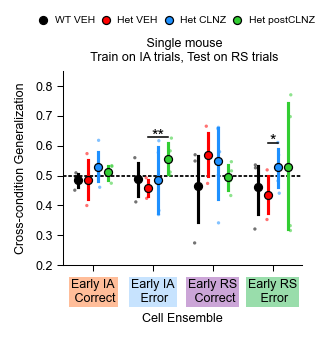

In [155]:
#### Single mouse CCGP: train IA, test RS (Figure 3B equivalent)
fig, ax_plot = plt.subplots(1, 1, figsize=ccgp_figsize, layout='constrained')

train_data = "train_Early_IA_Correct_Early_IA_Error"
decode_comp_3b = "Early IA Correct Early IA Error v Early RS Correct Early RS Error"
ensembles_3b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

posthoc_df_sm_3b = plot_single_mouse_ccgp(ax_plot, mouse_mean_ccgp,
    decoding_col="classes decoded",
    decode_comp=decode_comp_3b,
    enriched_group="enriched_group",
    ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=preset_comparison_list,
    marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 0.85],
    verbose_titles=["Single mouse", single_mouse_verbose_dicts[train_data][1]], scale=1)
add_xtick_color_boxes(ax_plot, ensembles_3b, stage_palette_dict)

hand, labs = ax_plot.get_legend_handles_labels()
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0), loc='lower center', ncols=4, frameon=False, title=None)

## save fig
fig_name = f"single_mouse_CCGP- {single_mouse_verbose_dicts[train_data][1]}_Early stage ens_ "
save_plot_record_as_csv_txt(posthoc_df_sm_3b, "r_1", fig_name, csv_folder_most_recent, None,
                            csv_suffix="single_mouse_ccgp_all_posthoc cohen d",
                            txt_suffix="single_mouse_ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name=fig_name, folder_key='r_1', filetypes_to_save=['pdf', 'png', 'svg'])


Saved r_1_single_mouse_CCGP (early ens) train_correct_test_error_single_mouse_ccgp_all_posthoc cohen d_20_Aug_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\r_1_single_mouse_CCGP (early ens) train_correct_test_error_single_mouse_ccgp_posthoc_results_text_20_Aug_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


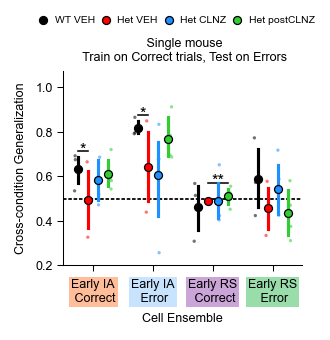

In [156]:
#### Single mouse CCGP: train Correct, test Error (Figure 4B equivalent)
fig, ax_plot = plt.subplots(1, 1, figsize=ccgp_figsize, layout='constrained')

train_data = "train_Early_IA_Correct_Early_RS_Correct"
decode_comp_4b = "Early IA Correct Early RS Correct v Early IA Error Early RS Error"
ensembles_4b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

posthoc_df_sm_4b = plot_single_mouse_ccgp(ax_plot, mouse_mean_ccgp,
    decoding_col="classes decoded",
    decode_comp=decode_comp_4b,
    enriched_group="enriched_group",
    ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=preset_comparison_list,
    marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 1.075],
    verbose_titles=["Single mouse", single_mouse_verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(ax_plot, ensembles_4b, stage_palette_dict)

## ax modifiers
hand, labs = ax_plot.get_legend_handles_labels()
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0), loc='lower center', ncols=4, frameon=False, title=None)

## save fig_posthoc
fig_name = f"single_mouse_CCGP (early ens) train_correct_test_error"
save_plot_record_as_csv_txt(posthoc_df_sm_4b, "r_1", fig_name, csv_folder_most_recent, None,
                            csv_suffix="single_mouse_ccgp_all_posthoc cohen d",
                            txt_suffix="single_mouse_ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name=fig_name, folder_key='r_1', filetypes_to_save=['pdf', 'png', 'svg'])


#### WT VEH only: each mouse's mean, error bar = that mouse's bootstrap PI
Same panel layout as the two figures above, but the hue is the **mouse** rather than the
genotype/day group, and the raw bootstrap rows are passed in rather than the mouse averages.
Each marker is one mouse's mean accuracy; each error bar is the 75% percentile interval across
that mouse's 1000 bootstraps.

Restricted to the 3 WT VEH mice. No posthoc tests are run: with 1000 bootstraps per mouse, a
mouse-versus-mouse test is significant by construction and is not the paper's comparison.


In [157]:
## WT VEH per-mouse plotting parameters
wt_veh_ccgp = single_mouse_ccgp.loc[single_mouse_ccgp.geno_day == "WT VEH", :]
wt_veh_mice = sorted(wt_veh_ccgp.subject_name.unique())

## grey ramp, one shade per mouse. Deliberately NOT the genotype palette: every mouse here is
## WT VEH, and the geno colours (red = Het VEH, blue = Het CLNZ) would misread as genotypes.
wt_veh_mouse_palette = ['black', 'dimgrey', 'darkgrey']
mouse_color_dict_no_errorbar = {'hue': 'subject_name',
                                'palette': wt_veh_mouse_palette[:len(wt_veh_mice)],
                                'hue_order': wt_veh_mice}
assert len(wt_veh_mice) <= len(wt_veh_mouse_palette), f"need a shade per mouse: {len(wt_veh_mice)} mice" 

print(f"WT VEH mice: {wt_veh_mice}")
print(f"bootstrap rows plotted per mouse per panel position: "
      f"{wt_veh_ccgp.groupby(['subject_name', 'enriched_group', 'classes decoded'], observed=True).size().unique()}")
display(wt_veh_ccgp.groupby('subject_name', observed=True)
        .agg(median_cells_per_decoder=('num_features_used', 'median'),
             n_bootstraps=('pseudopop_run_num', 'nunique')).reset_index())


WT VEH mice: ['5_3_WT_RS1', '6_2_WT_RS1', '7_5_WT_RS1']
bootstrap rows plotted per mouse per panel position: [1000]


,subject_name,median_cells_per_decoder,n_bootstraps
0,5_3_WT_RS1,5.5,1000
1,6_2_WT_RS1,5.5,1000
2,7_5_WT_RS1,10.5,1000


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


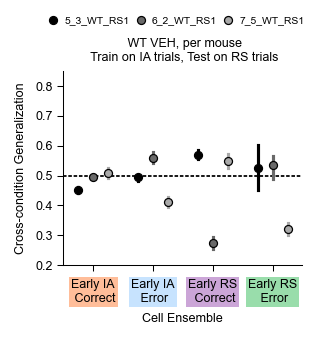

In [158]:
## WT VEH per-mouse: train IA, test RS (Figure 3B equivalent)
fig, ax_plot = plt.subplots(1, 1, figsize=ccgp_figsize, layout='constrained')

train_data = "train_Early_IA_Correct_Early_IA_Error"
decode_comp_3b = "Early IA Correct Early IA Error v Early RS Correct Early RS Error"
ensembles_3b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

plot_single_mouse_ccgp(ax_plot, wt_veh_ccgp,
    decoding_col="classes decoded",
    decode_comp=decode_comp_3b,
    enriched_group="enriched_group",
    ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=None, #see markdown: mouse-vs-mouse tests are not meaningful here
    marker_params=mouse_color_dict_no_errorbar,
    ylim=[0.2, 0.85],
    verbose_titles=["WT VEH, per mouse", single_mouse_verbose_dicts[train_data][1]],
    show_mouse_points=False, scale=1)
add_xtick_color_boxes(ax_plot, ensembles_3b, stage_palette_dict)

hand, labs = ax_plot.get_legend_handles_labels()
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0), loc='lower center', ncols=len(wt_veh_mice),
           frameon=False, title=None)

## save fig
fig_name = f"single_mouse_CCGP WT VEH per mouse- train IA test RS"
save_fig_in_main_fig_dir(fig, fig_name=fig_name, folder_key='r_1', filetypes_to_save=['pdf', 'png', 'svg'])


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


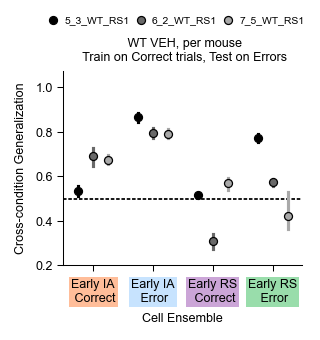

In [159]:
## WT VEH per-mouse: train Correct, test Error (Figure 4B equivalent)
fig, ax_plot = plt.subplots(1, 1, figsize=ccgp_figsize, layout='constrained')

train_data = "train_Early_IA_Correct_Early_RS_Correct"
decode_comp_4b = "Early IA Correct Early RS Correct v Early IA Error Early RS Error"
ensembles_4b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

plot_single_mouse_ccgp(ax_plot, wt_veh_ccgp,
    decoding_col="classes decoded",
    decode_comp=decode_comp_4b,
    enriched_group="enriched_group",
    ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=None,
    marker_params=mouse_color_dict_no_errorbar,
    ylim=[0.2, 1.075],
    verbose_titles=["WT VEH, per mouse", single_mouse_verbose_dicts[train_data][1]],
    show_mouse_points=False, scale=1.)
add_xtick_color_boxes(ax_plot, ensembles_4b, stage_palette_dict)

hand, labs = ax_plot.get_legend_handles_labels()
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0), loc='lower center', ncols=len(wt_veh_mice),
           frameon=False, title=None)

## save fig
fig_name = f"single_mouse_CCGP WT VEH per mouse- train correct test error"
save_fig_in_main_fig_dir(fig, fig_name=fig_name, folder_key='r_1', filetypes_to_save=['pdf', 'png', 'svg'])


## Reviewer analysis: IA and RS trials to completion (TTC)
Imports and cleans the behavioural trials-to-completion data for the initial association (IA)
and rule shift (RS) rules.

The import logic is copied from the **Figure 1 Behavior Analysis** cells of
`Revisions- Figure 1, 2 Plots v1.ipynb` so both notebooks read the same spreadsheets through
the same steps. It is a copy rather than an import because that logic lives in notebook cells,
not in a module.

Two source files, both in `data/`:
- `2024_Dlx Inscopix_Task Performance.xlsx` - per-mouse TTC and error counts per treatment day
- `Inscopix Mice Rules and Error types by session.xlsx` - perseverative / random error breakdown

The result is `behav_ttc`: one row per mouse per rule per treatment day.


In [160]:
#### Import behaviour spreadsheets (logic copied from Figure 1 Behavior Analysis)
dataset_xls = pd.read_excel(data_location / "2024_Dlx Inscopix_Task Performance.xlsx",
                            parse_dates=[2, 5, 12, 19], header=0, dtype=str)
dataset_xls['Age on Day 1-VEH'] = dataset_xls['Date run - VEH'] - dataset_xls['DOB']
dataset_xls['Age on Day 2-CLNZ'] = dataset_xls['Date run - CLZ'] - dataset_xls['DOB']
dataset_xls['Age on Day 3-postCLNZ'] = dataset_xls['Date run - POST'] - dataset_xls['DOB']

## set param cols
str_to_drop = ["Cells", "DOB", "Date", ">", "<", 'Age-Run1']
numeric_cols_flag = ["IA", "RS", "Cells"]
metadata_col = [e for e in dataset_xls.columns if any(match_str in e for match_str in str_to_drop)]
metadata_df = dataset_xls[metadata_col]
dataset_xls.drop(labels=metadata_col, axis=1, inplace=True)
dataset_xls.replace(to_replace="?", value=np.nan, inplace=True)
numeric_cols = [col for col in dataset_xls.columns if any(match_s in col for match_s in numeric_cols_flag)]
dataset_xls[numeric_cols] = dataset_xls[numeric_cols].apply(pd.to_numeric)
## add col calculating delay before postCLNZ injection
dataset_xls['delay_before_postCLNZ'] = dataset_xls.apply(
    lambda row: (row['Age on Day 3-postCLNZ'] - row['Age on Day 2-CLNZ']).days, axis=1)
ID_cols = [col for col in dataset_xls.columns
           if any(match_str in col for match_str in ['ID', 'Geno', 'elapsed', 'Sex', 'delay'])]

## merge in the perseverative / random error breakdown, then melt to long form
behav_detail_csv = 'Inscopix Mice Rules and Error types by session.xlsx'
behav_detail = pd.read_excel(data_location / behav_detail_csv, header=0)
behavior_details_df = dataset_xls.merge(
    behav_detail.loc[:, ['Mouse ID'] + [x for x in behav_detail.columns if "Error" in x]],
    how='left', on='Mouse ID').drop([x for x in dataset_xls.columns if "Age" in x], axis=1)
behav_long = behavior_details_df.melt(id_vars=ID_cols, var_name='Performance',
                                      value_name='measure').dropna(subset='measure')
## add description cols
behav_long['day'] = behav_long.Performance.str.rpartition("_")[2]        #treatment suffix
behav_long['data_type'] = behav_long.Performance.str.split("_").str.get(1) #measure type
behav_long['Performance'] = behav_long.Performance.str.rpartition("_")[0]  #rule + measure type
behav_long['rule'] = behav_long.Performance.str.split("_").str.get(0)      #rule prefix
behav_long['geno_day'] = behav_long['Geno'].str.cat(behav_long['day'], sep='_').map(
    {o: n for o, n in zip(["WT_VEH", "WT_CLNZ", "HET_VEH", "HET_CLNZ", "HET_postCLNZ"],
                          geno_order_w_WT_CLNZ)})
behav_long = behav_long.reset_index().drop('index', axis=1)

print(f"behav_long: {behav_long.shape} | geno_day: {behav_long.geno_day.unique()}")
print(f"Performance measures available: {sorted(behav_long.Performance.unique())}")
behav_long.tail(3)


behav_long: (296, 10) | geno_day: ['Het VEH' 'WT VEH' nan 'Het CLNZ' 'WT CLNZ' 'Het postCLNZ']
Performance measures available: ['IA_Errors_CLNZ', 'IA_Errors_VEH', 'IA_Errors_postCLNZ', 'IA_TTC', 'Perseverative_Error', 'RS_Errors_CLNZ', 'RS_Errors_VEH', 'RS_Errors_postCLNZ', 'RS_TTC', 'Random_Error']


,Mouse ID,Geno,Sex,delay_before_postCLNZ,Performance,measure,day,data_type,rule,geno_day
293,13-5,HET,M,11.0,Random_Error,0.0,postCLNZ,Error,Random,Het postCLNZ
294,13-8,HET,M,37.0,Random_Error,0.0,postCLNZ,Error,Random,Het postCLNZ
295,15-1,HET,M,48.0,Random_Error,1.0,postCLNZ,Error,Random,Het postCLNZ


In [161]:
#### Check the columns duplicated by the merge
## Six error columns exist in both spreadsheets, so the merge produced _x (Task Performance)
## and _y (Rules and Error types) copies. The melt keeps BOTH as separate rows under the same
## Performance name, so any disagreement would be silently pooled. Surface it here.
dup_base_cols = sorted({c[:-2] for c in behavior_details_df.columns if c.endswith(('_x', '_y'))
                        if f"{c[:-2]}_x" in behavior_details_df.columns
                        and f"{c[:-2]}_y" in behavior_details_df.columns})

merge_conflicts = []
for base_col in dup_base_cols:
    from_task_perf = pd.to_numeric(behavior_details_df[f"{base_col}_x"], errors='coerce')
    from_rules = pd.to_numeric(behavior_details_df[f"{base_col}_y"], errors='coerce')
    comparable = from_task_perf.notna() & from_rules.notna()
    for idx in behavior_details_df.index[comparable & (from_task_perf != from_rules)]:
        merge_conflicts.append({'column': base_col,
                                'Mouse ID': behavior_details_df.loc[idx, 'Mouse ID'],
                                'Geno': behavior_details_df.loc[idx, 'Geno'],
                                'task_performance_xlsx': from_task_perf[idx],
                                'rules_error_types_xlsx': from_rules[idx],
                                'difference': from_rules[idx] - from_task_perf[idx]})
merge_conflicts = pd.DataFrame(merge_conflicts)

print(f"columns duplicated by the merge: {dup_base_cols}")
if len(merge_conflicts) == 0:
    print("the duplicated copies agree everywhere")
else:
    print(f"WARNING: {len(merge_conflicts)} disagreements across "
          f"{merge_conflicts['Mouse ID'].nunique()} mice. The melt keeps both copies, so do not "
          f"analyse IA_Errors / RS_Errors from behav_long without resolving these first.")
    display(merge_conflicts)

## this section only needs TTC, which has no name collision in either spreadsheet
assert not any('TTC' in col for col in dup_base_cols), "a TTC column was duplicated by the merge"


columns duplicated by the merge: ['IA_Errors_CLNZ', 'IA_Errors_VEH', 'IA_Errors_postCLNZ', 'RS_Errors_CLNZ', 'RS_Errors_VEH', 'RS_Errors_postCLNZ']


,column,Mouse ID,Geno,task_performance_xlsx,rules_error_types_xlsx,difference
0,IA_Errors_CLNZ,7-2,WT,3.0,0.0,-3.0
1,RS_Errors_CLNZ,7-2,WT,3.0,6.0,3.0
2,RS_Errors_VEH,13-5,HET,10.0,11.0,1.0
3,RS_Errors_postCLNZ,13-5,HET,2.0,1.0,-1.0


In [162]:
#### Reduce to IA / RS TTC and check the cleaned frame
ttc_measures = ['IA_TTC', 'RS_TTC']
behav_ttc = behav_long.loc[behav_long.Performance.isin(ttc_measures), :].copy()
behav_ttc['measure'] = pd.to_numeric(behav_ttc['measure'])
behav_ttc['rule'] = behav_ttc['rule'].astype('category')

## sanity checks on the cleaned frame
## note: behav_long as a whole DOES carry NaN geno_day, but NOT for the reason it first looks.
## Six error column names exist in BOTH spreadsheets, so the merge renames them with pandas'
## _x / _y suffixes. `day` is parsed as the text after the last underscore, so for those rows
## day becomes 'x' or 'y' and the real treatment day stays stuck inside the Performance name
## (e.g. 'IA_Errors_VEH'). That is every IA_Errors / RS_Errors row.
## Perseverative_Error and Random_Error exist in only one file, never collide, keep their real
## day suffix, and map cleanly. TTC never collides either, so the TTC subset comes out clean.
assert behav_ttc.geno_day.notna().all(), "unmapped geno_day in the TTC subset"
assert not behav_ttc[['Mouse ID', 'Performance', 'geno_day']].duplicated().any(), \
    "duplicate mouse x measure x geno_day row"
assert behav_ttc.measure.gt(0).all(), "non-positive trials-to-completion value"
assert set(behav_ttc.Performance.unique()) == set(ttc_measures), "unexpected Performance value"

print(f"behav_ttc: {behav_ttc.shape} | mice: {behav_ttc['Mouse ID'].nunique()}")
print("Trials to completion by rule and group:")
display(behav_ttc.groupby(['Performance', 'geno_day'], observed=True)['measure']
        .agg(['count', 'mean', 'std', 'min', 'max']).round(2))
print("Mice per group:")
display(behav_ttc.groupby('geno_day', observed=True)['Mouse ID'].nunique().rename('n_mice'))
behav_ttc.head(3)


behav_ttc: (74, 10) | mice: 15
Trials to completion by rule and group:


count   mean   std   min   max
Performance geno_day                                    
IA_TTC      Het CLNZ          7  14.14  2.19  11.0  18.0
            Het VEH           7  13.57  2.76  11.0  18.0
            Het postCLNZ      7  13.14  2.12  11.0  16.0
            WT CLNZ           8  13.50  1.93  11.0  17.0
            WT VEH            8  14.12  1.89  11.0  17.0
RS_TTC      Het CLNZ          7  18.43  3.91  13.0  23.0
            Het VEH           7  26.43  3.99  21.0  32.0
            Het postCLNZ      7  18.86  5.15  12.0  25.0
            WT CLNZ           8  16.25  2.43  13.0  20.0
            WT VEH            8  15.50  4.93  12.0  27.0

Mice per group:


geno_day
Het CLNZ        7
Het VEH         7
Het postCLNZ    7
WT CLNZ         8
WT VEH          8
Name: n_mice, dtype: int64

,Mouse ID,Geno,Sex,delay_before_postCLNZ,Performance,measure,day,data_type,rule,geno_day
0,7-6,HET,M,41.0,IA_TTC,11.0,VEH,TTC,IA,Het VEH
1,10-3,HET,F,64.0,IA_TTC,18.0,VEH,TTC,IA,Het VEH
2,9-3,HET,F,10.0,IA_TTC,12.0,VEH,TTC,IA,Het VEH


#### TTC vs CCGP per mouse, faceted by ensemble
Two rows, one per trials-to-completion measure (IA then RS). Four columns, one per early
ensemble. Each point is one WT VEH mouse: x is that mouse's trials to completion, y is its mean
CCGP accuracy, and the vertical bar is the 75% percentile interval across its 1000 bootstraps.

CCGP is the train-Correct / test-Error comparison (the Figure 4B pair).

Read with care: there are **3 WT VEH mice**, so each panel holds 3 points. That is too few to
show whether TTC and CCGP are related, and no correlation or fit line is drawn for that reason.
The panels show the individual values, not a relationship.


In [165]:
## TTC vs CCGP- build the per-mouse frame
decode_comp_4b = "Early IA Correct Early RS Correct v Early IA Error Early RS Error"
ensembles_4b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

## CCGP: mouse mean plus the bootstrap PI, per ensemble
wt_ccgp_4b = wt_veh_ccgp.loc[(wt_veh_ccgp['classes decoded'] == decode_comp_4b)
                             & (wt_veh_ccgp.enriched_group.isin(ensembles_4b)), :]
ccgp_per_mouse = (wt_ccgp_4b.groupby(['subject_name', 'enriched_group'], observed=True)['accuracy']
                  .agg(ccgp_mean='mean',
                       ccgp_pi_low=lambda s: s.quantile(0.125),
                       ccgp_pi_high=lambda s: s.quantile(0.875)).reset_index())

## imaging subject_name -> behaviour Mouse ID ('5_3_WT_RS1' -> '5-3')
ccgp_per_mouse['Mouse ID'] = (ccgp_per_mouse.subject_name
                              .str.replace(r'_(HET|WT)_RS\d+$', '', regex=True)
                              .str.replace('_', '-'))

## TTC for the same treatment day these mice were imaged on (all 3 are RS1 = VEH)
ttc_wide = (behav_ttc.loc[behav_ttc.geno_day == "WT VEH", :]
            .pivot(index='Mouse ID', columns='Performance', values='measure'))

ttc_ccgp = ccgp_per_mouse.merge(ttc_wide, on='Mouse ID', how='left')
assert ttc_ccgp[['IA_TTC', 'RS_TTC']].notna().all().all(), "a mouse is missing its TTC values"
assert ttc_ccgp.subject_name.nunique() == wt_veh_ccgp.subject_name.nunique(), "lost a mouse in the merge"

ttc_ccgp_long = ttc_ccgp.melt(
    id_vars=['subject_name', 'Mouse ID', 'enriched_group', 'ccgp_mean', 'ccgp_pi_low', 'ccgp_pi_high'],
    value_vars=['IA_TTC', 'RS_TTC'], var_name='ttc_measure', value_name='ttc')

print(f"mice: {ttc_ccgp.subject_name.nunique()} | rows per panel: "
      f"{len(ttc_ccgp_long) // (2 * len(ensembles_4b))}")
display(ttc_ccgp)


mice: 3 | rows per panel: 3


,subject_name,enriched_group,ccgp_mean,ccgp_pi_low,ccgp_pi_high,Mouse ID,IA_TTC,RS_TTC
0,5_3_WT_RS1,Early_IA_Correct,0.534876,0.513672,0.556641,5-3,17.0,16.0
1,5_3_WT_RS1,Early_IA_Error,0.865577,0.843750,0.884766,5-3,17.0,16.0
2,5_3_WT_RS1,Early_RS_Correct,0.514250,0.509766,0.518555,5-3,17.0,16.0
3,5_3_WT_RS1,Early_RS_Error,0.773132,0.753906,0.791016,5-3,17.0,16.0
4,6_2_WT_RS1,Early_IA_Correct,0.692480,0.648376,0.728027,6-2,15.0,15.0
5,6_2_WT_RS1,Early_IA_Error,0.796518,0.772949,0.819336,6-2,15.0,15.0
6,6_2_WT_RS1,Early_RS_Correct,0.308371,0.274658,0.339630,6-2,15.0,15.0
7,6_2_WT_RS1,Early_RS_Error,0.572502,0.555664,0.589844,6-2,15.0,15.0
8,7_5_WT_RS1,Early_IA_Correct,0.675053,0.655762,0.693848,7-5,14.0,16.0
9,7_5_WT_RS1,Early_IA_Error,0.791655,0.770508,0.813477,7-5,14.0,16.0


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\20_Aug_2026' already exists.


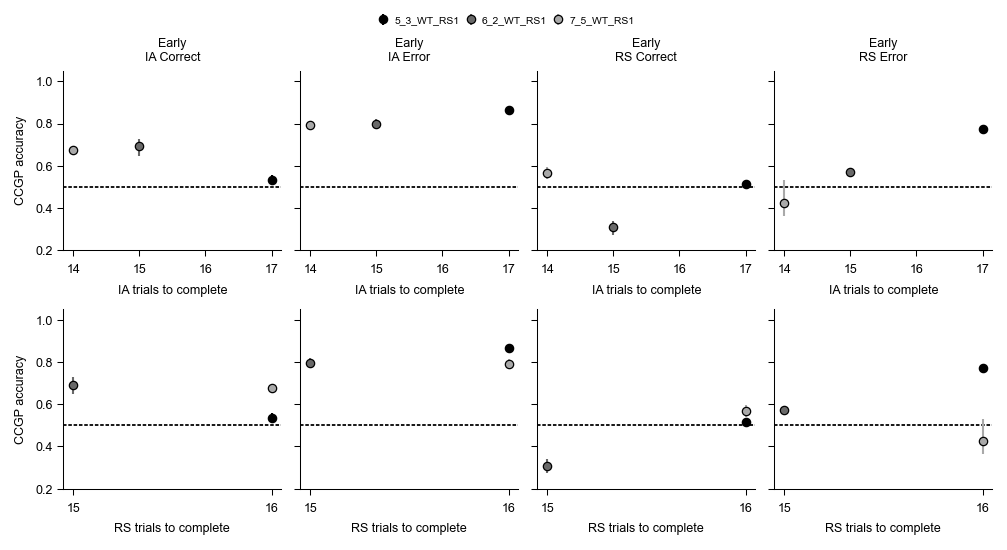

In [166]:
## TTC vs CCGP- 2 rows (TTC measure) x 4 columns (ensemble)
ttc_rows = ['IA_TTC', 'RS_TTC']
row_xlabels = {'IA_TTC': 'IA trials to complete', 'RS_TTC': 'RS trials to complete'}
mouse_shade = dict(zip(wt_veh_mice, wt_veh_mouse_palette[:len(wt_veh_mice)]))

fig, axes = plt.subplots(len(ttc_rows), len(ensembles_4b), figsize=(6.6, 3.4),
                         layout='constrained', sharey=True)
for row_i, ttc_measure in enumerate(ttc_rows):
    for col_i, ensemble in enumerate(ensembles_4b):
        ax_plot = axes[row_i, col_i]
        panel = ttc_ccgp_long.loc[(ttc_ccgp_long.ttc_measure == ttc_measure)
                                  & (ttc_ccgp_long.enriched_group == ensemble), :]
        for _, mouse_row in panel.iterrows():
            ax_plot.errorbar(
                mouse_row['ttc'], mouse_row['ccgp_mean'],
                yerr=[[mouse_row['ccgp_mean'] - mouse_row['ccgp_pi_low']],
                      [mouse_row['ccgp_pi_high'] - mouse_row['ccgp_mean']]],
                fmt='o', ms=4, mfc=mouse_shade[mouse_row['subject_name']], mec='black', mew=0.6,
                ecolor=mouse_shade[mouse_row['subject_name']], elinewidth=1, capsize=0, zorder=3,
                label=mouse_row['subject_name'] if (row_i == 0 and col_i == 0) else None)
        ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)
        ax_plot.set_ylim(0.2, 1.05)
        ax_plot.xaxis.get_major_locator().set_params(integer=True)
        if row_i == 0: #ensemble names label the columns
            ax_plot.set_title(ensemble.replace('_', ' ').replace(' ', '\n', 1))
        ## the x variable CHANGES between rows, so every row carries its own x label
        ax_plot.set_xlabel(row_xlabels[ttc_measure])
        ax_plot.set_ylabel('CCGP accuracy' if col_i == 0 else None)

hand, labs = axes[0, 0].get_legend_handles_labels()
fig.legend(hand, labs, bbox_to_anchor=(0.5, 1.0), loc='lower center',
           ncols=len(wt_veh_mice), frameon=False, title=None)

fig_name = "single_mouse_CCGP WT VEH- TTC vs CCGP by ensemble"
save_fig_in_main_fig_dir(fig, fig_name=fig_name, folder_key='r_1', filetypes_to_save=['pdf', 'png', 'svg'])


#### TTC vs CCGP, all 16 mice
Same layout as the WT VEH panels above, but every eligible mouse is included: 16 mouse-sessions
across all five treatment groups, coloured by geno_day.

Each mouse is joined to its OWN treatment day's behaviour, on (Mouse ID, geno_day). A mouse
imaged on the CLNZ day is matched to its CLNZ trials-to-completion, not its VEH values.

This version has a real x range. RS trials to completion spans 13 to 31 here, against 15 to 16
for the three WT VEH mice, so a relationship could actually show up. Spearman rho is annotated
per panel because it does not assume a straight line and holds up at n = 16.

One caveat before reading the rho values: the 16 points mix five treatment groups. Het VEH mice
take many more RS trials AND are a different condition, so any correlation partly reflects the
treatment difference rather than a within-mouse link between behaviour and decoding.


In [167]:
## TTC vs CCGP (all mice)- build the per-mouse frame
ccgp_all_4b = mouse_mean_ccgp.loc[(mouse_mean_ccgp['classes decoded'] == decode_comp_4b)
                                  & (mouse_mean_ccgp.enriched_group.isin(ensembles_4b)), :]

## bootstrap PI needs the raw rows, so recompute from single_mouse_ccgp
ccgp_all_per_mouse = (single_mouse_ccgp
                      .loc[(single_mouse_ccgp['classes decoded'] == decode_comp_4b)
                           & (single_mouse_ccgp.enriched_group.isin(ensembles_4b)), :]
                      .groupby(['subject_name', 'geno_day', 'enriched_group'], observed=True)['accuracy']
                      .agg(ccgp_mean='mean',
                           ccgp_pi_low=lambda s: s.quantile(0.125),
                           ccgp_pi_high=lambda s: s.quantile(0.875)).reset_index())
ccgp_all_per_mouse['Mouse ID'] = (ccgp_all_per_mouse.subject_name
                                  .str.replace(r'_(HET|WT)_RS\d+$', '', regex=True)
                                  .str.replace('_', '-'))

## behaviour: keep the treatment day each mouse was actually imaged on
ttc_by_mouse_day = (behav_ttc.pivot_table(index=['Mouse ID', 'geno_day'], columns='Performance',
                                          values='measure', observed=True).reset_index())
ttc_ccgp_all = ccgp_all_per_mouse.merge(ttc_by_mouse_day, on=['Mouse ID', 'geno_day'], how='left')

assert ttc_ccgp_all[['IA_TTC', 'RS_TTC']].notna().all().all(), "a mouse-session is missing its TTC values"
assert ttc_ccgp_all.subject_name.nunique() == mouse_mean_ccgp.subject_name.nunique(), "lost a mouse in the merge"

ttc_ccgp_all_long = ttc_ccgp_all.melt(
    id_vars=['subject_name', 'Mouse ID', 'geno_day', 'enriched_group',
             'ccgp_mean', 'ccgp_pi_low', 'ccgp_pi_high'],
    value_vars=['IA_TTC', 'RS_TTC'], var_name='ttc_measure', value_name='ttc')

print(f"mouse-sessions: {ttc_ccgp_all.subject_name.nunique()} | points per panel: "
      f"{len(ttc_ccgp_all_long) // (2 * len(ensembles_4b))}")
print(f"IA_TTC range: {ttc_ccgp_all.IA_TTC.min():.0f}-{ttc_ccgp_all.IA_TTC.max():.0f} | "
      f"RS_TTC range: {ttc_ccgp_all.RS_TTC.min():.0f}-{ttc_ccgp_all.RS_TTC.max():.0f}")
display(ttc_ccgp_all.groupby('geno_day', observed=True)['subject_name'].nunique().rename('n_mice'))


mouse-sessions: 16 | points per panel: 16
IA_TTC range: 13-18 | RS_TTC range: 13-31


geno_day
Het CLNZ        5
Het VEH         2
Het postCLNZ    4
WT CLNZ         2
WT VEH          3
Name: n_mice, dtype: int64

,ttc_measure,enriched_group,n_mice,spearman_rho,pvalue
0,IA_TTC,Early_IA_Correct,16,-0.146,0.590
1,IA_TTC,Early_IA_Error,16,0.153,0.571
2,IA_TTC,Early_RS_Correct,16,-0.187,0.489
3,IA_TTC,Early_RS_Error,16,-0.078,0.773
4,RS_TTC,Early_IA_Correct,16,-0.194,0.472
5,RS_TTC,Early_IA_Error,16,0.068,0.802
6,RS_TTC,Early_RS_Correct,16,-0.012,0.965
7,RS_TTC,Early_RS_Error,16,-0.463,0.071


Saved r_1_single_mouse_CCGP all mice- TTC vs CCGP by ensemble_ttc_vs_ccgp_spearman_20_Aug_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output


AttributeError: 'Series' object has no attribute 'numeric_var'

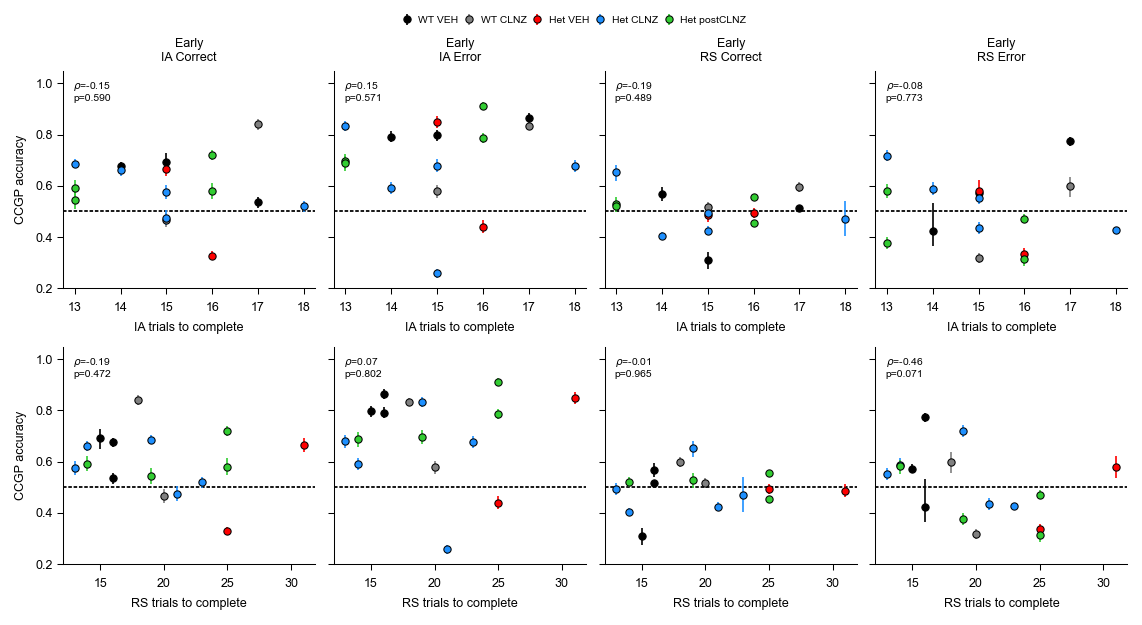

In [168]:
## TTC vs CCGP (all mice)- 2 rows (TTC measure) x 4 columns (ensemble)
from scipy.stats import spearmanr

geno_shade = dict(zip(geno_order_w_WT_CLNZ, color_list_WT_CLNZ))
ttc_corr_records = []

fig, axes = plt.subplots(len(ttc_rows), len(ensembles_4b), figsize=(7.5, 3.9),
                         layout='constrained', sharey=True)
for row_i, ttc_measure in enumerate(ttc_rows):
    for col_i, ensemble in enumerate(ensembles_4b):
        ax_plot = axes[row_i, col_i]
        panel = ttc_ccgp_all_long.loc[(ttc_ccgp_all_long.ttc_measure == ttc_measure)
                                      & (ttc_ccgp_all_long.enriched_group == ensemble), :]
        for geno in geno_order_w_WT_CLNZ: #one errorbar call per group so the legend stays clean
            grp = panel.loc[panel.geno_day == geno, :]
            if len(grp) == 0:
                continue
            ax_plot.errorbar(grp['ttc'], grp['ccgp_mean'],
                             yerr=[grp['ccgp_mean'] - grp['ccgp_pi_low'],
                                   grp['ccgp_pi_high'] - grp['ccgp_mean']],
                             fmt='o', ms=3.5, mfc=geno_shade[geno], mec='black', mew=0.5,
                             ecolor=geno_shade[geno], elinewidth=0.8, capsize=0, linestyle='none',
                             zorder=3, label=geno if (row_i == 0 and col_i == 0) else None)

        ## Spearman: rank based, so no straight-line assumption at n=16
        rho, pval = spearmanr(panel['ttc'], panel['ccgp_mean'])
        ttc_corr_records.append({'ttc_measure': ttc_measure, 'enriched_group': ensemble,
                                 'n_mice': len(panel), 'spearman_rho': rho, 'pvalue': pval})
        ax_plot.annotate(f"$\\rho$={rho:.2f}\np={pval:.3f}", xy=(0.04, 0.96),
                         xycoords='axes fraction', va='top', ha='left', fontsize=5)

        ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)
        ax_plot.set_ylim(0.2, 1.05)
        ax_plot.xaxis.get_major_locator().set_params(integer=True)
        if row_i == 0:
            ax_plot.set_title(ensemble.replace('_', ' ').replace(' ', '\n', 1))
        ax_plot.set_xlabel(row_xlabels[ttc_measure]) #x variable changes between rows
        ax_plot.set_ylabel('CCGP accuracy' if col_i == 0 else None)

hand, labs = axes[0, 0].get_legend_handles_labels()
fig.legend(hand, labs, bbox_to_anchor=(0.5, 1.0), loc='lower center',
           ncols=len(geno_order_w_WT_CLNZ), frameon=False, title=None)

ttc_corr_df = pd.DataFrame(ttc_corr_records)
display(ttc_corr_df.round(3))

fig_name = "single_mouse_CCGP all mice- TTC vs CCGP by ensemble"
save_plot_record_as_csv_txt(ttc_corr_df, "r_1", fig_name, csv_folder_most_recent, None,
                            csv_suffix="ttc_vs_ccgp_spearman", txt_suffix="ttc_vs_ccgp_text")
save_fig_in_main_fig_dir(fig, fig_name=fig_name, folder_key='r_1', filetypes_to_save=['pdf', 'png', 'svg'])
